# Axisymmetric space-charge electric-field kernel for the sPHENIX TPC

This notebook constructs an axisymmetric response kernel

$$
K_r(r,z;r',z')=\frac{E_r(r,z)}{Q_{\rm source}},
\qquad
K_z(r,z;r',z')=\frac{E_z(r,z)}{Q_{\rm source}},
$$

for finite annular source voxels in one half of the sPHENIX TPC.

The simplifying assumptions are:

1. the charge density is uniform in azimuth, so only the $m_\phi=0$ mode is retained;
2. the first physical charge model is uniform in $z$;
3. the default radial shape is $\rho(r)\propto 1/r$;
4. the perturbation potential is zero at the inner and outer field cages, the central membrane, and the readout plane;
5. only the electric field generated by the space charge is calculated here. The nominal drift field is added separately later.

The notebook deliberately keeps the full $(r,z;r',z')$ kernel even for the initial $z$-uniform model. This allows the same kernel to be reused for nonuniform longitudinal profiles without repeating the expensive eigenmode preparation.

The implementation follows the Green-function/eigenfunction strategy described in Chapter 5 of Stefan Rossegger's thesis and the factorization presented in the sPHENIX *Lost in Space* slides. The production source is a finite annular voxel rather than a mathematical point source, avoiding the singular diagonal field and improving mode convergence.

## 0. Physics conventions and units

All internal calculations use SI units:

- radius and longitudinal coordinate: metres;
- charge density: $\mathrm{C\,m^{-3}}$;
- source charge: coulombs;
- electric field: $\mathrm{V\,m^{-1}}$;
- kernel: $(\mathrm{V\,m^{-1}})/\mathrm{C}$.

The perturbation potential obeys

$$
\nabla^2\delta\Phi=-\frac{\rho}{\epsilon_0},
\qquad
\delta\mathbf E=-\nabla\delta\Phi.
$$

For one TPC half, the domain is

$$
a\le r\le b,\qquad 0\le z\le L.
$$

The boundaries are held at fixed nominal potentials. Therefore the *space-charge perturbation* satisfies homogeneous Dirichlet conditions,

$$
\delta\Phi(a,z)=\delta\Phi(b,z)=
\delta\Phi(r,0)=\delta\Phi(r,L)=0.
$$

The electric field itself does not generally vanish at these boundaries; induced surface charge is exactly what enforces the fixed-potential condition.

In [1]:
# ============================================================
# USER CONFIGURATION: all flags and parameters are defined here
# ============================================================

# Master switches
DO_QA = True
DO_GAUSS_TEST = True
DO_FD_CROSSCHECK = True
WRITE_ROOT_OUTPUT = True
ROOT_BATCH_MODE = True
VERBOSE = True

# Rebuild/caching controls
REBUILD_RADIAL_MODES = True
REBUILD_KERNEL = True
CACHE_DIRECTORY = "spacecharge_cache"
OUTPUT_ROOT_FILE = "sphenix_axisymmetric_spacecharge_kernel.root"

# Physical conducting boundaries used by the Green function
R_FIELD_CAGE_INNER_CM = 20.0
R_FIELD_CAGE_OUTER_CM = 75.911
DRIFT_LENGTH_CM = 102.325


# Region containing the initial ion-backflow source model
R_SOURCE_MIN_CM = 31.105
R_SOURCE_MAX_CM = 75.911

# Region where fields and distortions are evaluated for tracking
R_OBSERVATION_MIN_CM = 31.105
R_OBSERVATION_MAX_CM = 75.911

# Initial coarse grid.
# "Larger" spacing keeps the first full 4D kernel fast.
# These are edges; observation and source coordinates are cell centers.
DR_CM = 4.0
DZ_CM = 4.0

# Eigenmode truncation. Increase these only after convergence QA.
N_RADIAL_MODES = 36
N_LONGITUDINAL_MODES = 48

# Source-voxel integration
RADIAL_QUADRATURE_ORDER = 8

# Default charge model
CHARGE_PROFILE = "1/r2"       # choices: "uniform", "1/r", "1/r2"
Z_PROFILE = "uniform"        # first implementation
RHO_REFERENCE_NC_PER_M3 = 20.0

# Optional amplitude scan around the reference density
RHO_SCALE_FACTORS = [0.25, 0.5, 1.0, 2.0, 4.0]

# Numerical controls
ROOT_SCAN_POINTS = 20000
ROOT_BRENT_XTOL = 1.0e-12
MODE_ZERO_TOL = 1.0e-14
FIELD_FLOOR_V_PER_M = 1.0e-20
GAUSS_QUADRATURE_ORDER = 80

# Finite-difference validation grid
FD_NR = 91
FD_NZ = 121

# Plot controls
QA_SOURCE_INDICES = None  # None -> automatically choose representative sources
MAX_QA_SOURCES = 6


# QA image output
QA_PLOT_DIRECTORY = "spacecharge_qa_plots"
SAVE_QA_PNG = True
DISPLAY_QA_PLOTS_INLINE = True

# Provisional first-order electron-transport parameters.
# These affect only the distortion QA, not the electrostatic kernel.
NOMINAL_DRIFT_FIELD_V_PER_CM = 400.0
OMEGA_TAU = 2.3
DISTORTION_INTEGRATION_DIRECTION = "to_readout"

# Physical constants
EPSILON_0 = 8.8541878128e-12  # F/m
ELEMENTARY_CHARGE_C = 1.602176634e-19

## 1. Imports

`ROOT` is used for the final file format and QA histograms. NumPy and SciPy are used for dense linear algebra, Bessel functions, root finding, interpolation, sparse Poisson validation, and Gaussian quadrature.

The expensive four-dimensional object is not filled with Python loops. Instead, the field kernel is factorized into observation-mode and source-mode matrices and assembled with matrix multiplication.

In [2]:
import os
import json
import math
import time
from pathlib import Path

import numpy as np
import scipy
from scipy import special, optimize, sparse
from scipy.sparse import linalg as sparse_linalg
from scipy.interpolate import RegularGridInterpolator
from numpy.polynomial.legendre import leggauss

import ROOT as root
from IPython.display import display, Image

if ROOT_BATCH_MODE:
    root.gROOT.SetBatch(True)

Path(CACHE_DIRECTORY).mkdir(parents=True, exist_ok=True)

print("ROOT version :", root.gROOT.GetVersion())
print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)
Path(QA_PLOT_DIRECTORY).mkdir(parents=True, exist_ok=True)

Welcome to JupyROOT 6.30/06
ROOT version : 6.30/06
NumPy version: 1.26.4
SciPy version: 1.14.1


## 2. Build the observation and source grids

The same grid is initially used for observation and source coordinates. The source cells are finite annular volumes,

$$
V_{kl}=\pi\left(r_{k,+}^2-r_{k,-}^2\right)
       \left(z_{l,+}-z_{l,-}\right).
$$

The factor of $\pi(r_+^2-r_-^2)$ is the full $2\pi$ azimuthal integral of $r\,dr$. This cylindrical Jacobian must be included whenever density is converted into charge.

With the default $4\ \mathrm{cm}$ spacing, the first kernel is intentionally coarse enough to generate quickly. Later, the same code can be rerun with $2\ \mathrm{cm}$, $1\ \mathrm{cm}$, or nonuniform edges after convergence and physics QA are satisfactory.

In [ ]:
CM_TO_M = 1.0e-2

a = R_INNER_CM * CM_TO_M
b = R_OUTER_CM * CM_TO_M
L = DRIFT_LENGTH_CM * CM_TO_M
dr_target = DR_CM * CM_TO_M
dz_target = DZ_CM * CM_TO_M

def make_edges(xmin, xmax, target_step):
    n = int(np.ceil((xmax - xmin) / target_step))
    return np.linspace(xmin, xmax, n + 1, dtype=np.float64)

r_edges = make_edges(a, b, dr_target)
z_edges = make_edges(0.0, L, dz_target)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

nr = len(r_centers)
nz = len(z_centers)
nvox = nr * nz

radial_areas = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2)
cell_dz = np.diff(z_edges)
cell_volumes = radial_areas[:, None] * cell_dz[None, :]

assert cell_volumes.shape == (nr, nz)
assert np.all(cell_volumes > 0)

print(f"Geometry: a={a:.6f} m, b={b:.6f} m, L={L:.6f} m")
print(f"Grid: nr={nr}, nz={nz}, voxels={nvox}")
print(f"Kernel elements per component: {nvox*nvox:,}")
print(f"Approximate two-component float64 size: "
      f"{2*nvox*nvox*8/1024**2:.2f} MiB")
print(f"Active volume, one side: {cell_volumes.sum():.6f} m^3")
print(f"Active volume, two sides: {2*cell_volumes.sum():.6f} m^3")

Geometry: a=0.200000 m, b=0.759110 m, L=1.023250 m
Grid: nr=14, nz=26, voxels=364
Kernel elements per component: 132,496
Approximate two-component float64 size: 2.02 MiB
Active volume, one side: 1.723841 m^3
Active volume, two sides: 3.447683 m^3


## 3. Axisymmetric eigenfunctions in an annular cylinder

For azimuthal symmetry, separation of variables gives

$$
\psi_{nm}(r,z)=R_n(r)\sin(q_m z),
\qquad q_m=\frac{m\pi}{L},
\qquad m=1,2,\ldots
$$

The radial function satisfies the order-zero Bessel equation and vanishes at both field cages. A convenient unnormalized form is

$$
R_n(r)=
J_0(k_n r)Y_0(k_n a)
-
Y_0(k_n r)J_0(k_n a).
$$

It automatically vanishes at $r=a$. The allowed $k_n$ values are roots of

$$
J_0(k_n b)Y_0(k_n a)
-
Y_0(k_n b)J_0(k_n a)=0.
$$

The eigenvalue of $-\nabla^2$ is

$$
\lambda_{nm}=k_n^2+q_m^2.
$$

The radial derivative needed for $E_r$ is

$$
\frac{dR_n}{dr}
=
-k_nJ_1(k_n r)Y_0(k_n a)
+k_nY_1(k_n r)J_0(k_n a).
$$

The basis is orthogonal with cylindrical weight $r$. The radial normalization is

$$
N_n^{(r)}=\int_a^b r\,R_n^2(r)\,dr,
$$

and the longitudinal normalization is $N_m^{(z)}=L/2$.

In [ ]:
def radial_boundary_function(k):
    return (
        special.jv(0, k*b) * special.yv(0, k*a)
        - special.yv(0, k*b) * special.jv(0, k*a)
    )

def radial_basis(k, r):
    r = np.asarray(r)
    return (
        special.jv(0, k*r) * special.yv(0, k*a)
        - special.yv(0, k*r) * special.jv(0, k*a)
    )

def radial_basis_derivative(k, r):
    r = np.asarray(r)
    return (
        -k * special.jv(1, k*r) * special.yv(0, k*a)
        +k * special.yv(1, k*r) * special.jv(0, k*a)
    )

def find_radial_roots(n_roots, scan_points=ROOT_SCAN_POINTS):
    # Asymptotically the spacing is close to pi/(b-a).
    spacing = np.pi / (b - a)
    k_max = (n_roots + 8) * spacing
    x = np.linspace(max(1.0e-8, 1.0e-5*spacing), k_max, scan_points)
    y = radial_boundary_function(x)

    roots = []
    for i in range(len(x)-1):
        if not (np.isfinite(y[i]) and np.isfinite(y[i+1])):
            continue
        if y[i] == 0.0:
            candidate = x[i]
        elif y[i] * y[i+1] < 0.0:
            candidate = optimize.brentq(
                radial_boundary_function,
                x[i], x[i+1],
                xtol=ROOT_BRENT_XTOL
            )
        else:
            continue

        if not roots or abs(candidate - roots[-1]) > 1.0e-8*spacing:
            roots.append(candidate)
            if len(roots) == n_roots:
                return np.asarray(roots, dtype=np.float64)

    raise RuntimeError(
        f"Found only {len(roots)} radial roots; increase ROOT_SCAN_POINTS or k_max."
    )

roots_cache = Path(CACHE_DIRECTORY) / (
    f"radial_roots_a{a:.6f}_b{b:.6f}_N{N_RADIAL_MODES}.npz"
)

if roots_cache.exists() and not REBUILD_RADIAL_MODES:
    k_modes = np.load(roots_cache)["k_modes"]
else:
    t0 = time.time()
    k_modes = find_radial_roots(N_RADIAL_MODES)
    np.savez_compressed(roots_cache, k_modes=k_modes)
    print(f"Found {len(k_modes)} radial roots in {time.time()-t0:.2f} s")

q_modes = np.arange(1, N_LONGITUDINAL_MODES+1, dtype=np.float64) * np.pi / L

print("First radial k values [1/m]:", k_modes[:5])
print("First longitudinal q values [1/m]:", q_modes[:5])

Found 36 radial roots in 0.05 s
First radial k values [1/m]: [ 6.94419    13.98666242 21.00988805 28.02748585 35.04271746]
First longitudinal q values [1/m]: [ 3.07021026  6.14042053  9.21063079 12.28084106 15.35105132]


## 4. Normalize the radial basis

The Green-function expansion is simplest when the radial and longitudinal normalization factors are explicit. Numerical Gauss-Legendre integration is used for the radial norms because it is stable, fast, and independent of any special-function normalization convention.

A first QA check is that each mode is nearly zero at both $r=a$ and $r=b$, and that the overlap matrix is nearly diagonal.

In [ ]:
def gauss_integrate_interval(func, xmin, xmax, order=128):
    xg, wg = leggauss(order)
    x = 0.5*(xmax-xmin)*xg + 0.5*(xmax+xmin)
    return 0.5*(xmax-xmin) * np.sum(wg * func(x))

radial_norms = np.array([
    gauss_integrate_interval(
        lambda rr, kk=k: rr * radial_basis(kk, rr)**2,
        a, b, order=max(128, 4*N_RADIAL_MODES)
    )
    for k in k_modes
])

if np.any(~np.isfinite(radial_norms)) or np.any(radial_norms <= 0):
    raise RuntimeError("Invalid radial mode normalization.")

if DO_QA:
    boundary_a = np.array([radial_basis(k, a) for k in k_modes])
    boundary_b = np.array([radial_basis(k, b) for k in k_modes])

    print("max |R_n(a)| =", np.max(np.abs(boundary_a)))
    print("max |R_n(b)| =", np.max(np.abs(boundary_b)))

    ncheck = min(10, N_RADIAL_MODES)
    overlap = np.zeros((ncheck, ncheck))
    for i in range(ncheck):
        for j in range(ncheck):
            overlap[i, j] = gauss_integrate_interval(
                lambda rr, ii=i, jj=j:
                    rr * radial_basis(k_modes[ii], rr)
                       * radial_basis(k_modes[jj], rr),
                a, b, order=256
            )
    normalized_overlap = overlap / np.sqrt(
        radial_norms[:ncheck, None] * radial_norms[None, :ncheck]
    )
    print("Largest off-diagonal normalized radial overlap:",
          np.max(np.abs(normalized_overlap - np.eye(ncheck))))

max |R_n(a)| = 0.0
max |R_n(b)| = 3.896188927043909e-15
Largest off-diagonal normalized radial overlap: 2.270821468110885e-14


## 5. Projection of a finite annular source voxel

For a source voxel $(k,l)$, the total charge is $Q_{kl}$, and its density is uniform inside that voxel:

$$
\rho_{kl}=\frac{Q_{kl}}{V_{kl}}.
$$

The modal source integral is

$$
S_{nm}^{(kl)}
=
\int_{\mathrm{cell}}
\rho_{kl}\,R_n(r')\sin(q_mz')\,r'\,dr'\,dz'.
$$

Because $Q_{kl}$ is the full three-dimensional charge and the reduced Poisson equation is axisymmetric, the density contains the full annular volume factor $2\pi r'\,dr'\,dz'$. For a kernel normalized per coulomb,

$$
\frac{S_{nm}^{(kl)}}{Q_{kl}}
=
\frac{
\left[\int_{r_-}^{r_+}r'R_n(r')dr'\right]
\left[\int_{z_-}^{z_+}\sin(q_mz')dz'\right]
}{
2\pi
\left[\int_{r_-}^{r_+}r'dr'\right]
(z_+-z_-)
}.
$$

This finite-cell average regularizes the source and gives a well-defined diagonal response.

In [ ]:
def build_source_projection():
    # radial_integrals[ir, n] = integral r R_n(r) dr over radial source cell
    radial_integrals = np.zeros((nr, N_RADIAL_MODES), dtype=np.float64)
    xg, wg = leggauss(RADIAL_QUADRATURE_ORDER)

    for ir in range(nr):
        rlo, rhi = r_edges[ir], r_edges[ir+1]
        rr = 0.5*(rhi-rlo)*xg + 0.5*(rhi+rlo)
        jac = 0.5*(rhi-rlo)
        basis_values = np.stack(
            [radial_basis(k, rr) for k in k_modes], axis=1
        )
        radial_integrals[ir, :] = jac * np.sum(
            wg[:, None] * rr[:, None] * basis_values,
            axis=0
        )

    # z_integrals[iz, m] = integral sin(q_m z) dz over z source cell
    zlo = z_edges[:-1, None]
    zhi = z_edges[1:, None]
    z_integrals = (
        np.cos(q_modes[None, :] * zlo)
        - np.cos(q_modes[None, :] * zhi)
    ) / q_modes[None, :]

    # Reduced volume factor:
    # full cell volume = 2*pi * (integral r dr) * dz
    radial_measure = 0.5*(r_edges[1:]**2 - r_edges[:-1]**2)
    dz = np.diff(z_edges)

    # Flatten source index as q = ir*nz + iz
    source_projection = np.empty(
        (nvox, N_RADIAL_MODES*N_LONGITUDINAL_MODES),
        dtype=np.float64
    )

    for ir in range(nr):
        for iz in range(nz):
            q = ir*nz + iz
            per_coulomb = np.outer(
                radial_integrals[ir, :],
                z_integrals[iz, :]
            )
            per_coulomb /= (
                2.0*np.pi * radial_measure[ir] * dz[iz]
            )
            source_projection[q, :] = per_coulomb.ravel()

    return source_projection

source_projection = build_source_projection()
print("Source-projection matrix shape:", source_projection.shape)

Source-projection matrix shape: (312, 1728)


## 6. Observation matrices and kernel assembly

Expanding the potential in the eigenbasis gives

$$
\Phi_{nm}
=
\frac{1}{\epsilon_0}
\frac{S_{nm}}
{\lambda_{nm}N_n^{(r)}(L/2)}.
$$

At an observation point,

$$
E_r(r,z)=
-\sum_{nm}
\Phi_{nm}
\frac{dR_n}{dr}\sin(q_mz),
$$

$$
E_z(r,z)=
-\sum_{nm}
\Phi_{nm}
R_n(r)q_m\cos(q_mz).
$$

The complete four-dimensional kernel is therefore a matrix product:

$$
K_\alpha = O_\alpha S^T,
$$

where rows of $O_\alpha$ correspond to observation cells and rows of $S$ correspond to source cells. This factorization is the main computational speedup.

In [ ]:
lambda_nm = k_modes[:, None]**2 + q_modes[None, :]**2
normalization_nm = (
    EPSILON_0
    * lambda_nm
    * radial_norms[:, None]
    * (L/2.0)
)

def build_observation_matrices(r_values, z_values):
    r_values = np.asarray(r_values, dtype=np.float64)
    z_values = np.asarray(z_values, dtype=np.float64)

    R = np.stack([radial_basis(k, r_values) for k in k_modes], axis=1)
    dR = np.stack(
        [radial_basis_derivative(k, r_values) for k in k_modes],
        axis=1
    )
    SZ = np.sin(z_values[:, None] * q_modes[None, :])
    CZ = np.cos(z_values[:, None] * q_modes[None, :])

    nobs = len(r_values) * len(z_values)
    O_r = np.empty((nobs, N_RADIAL_MODES*N_LONGITUDINAL_MODES))
    O_z = np.empty_like(O_r)

    p = 0
    for ir in range(len(r_values)):
        for iz in range(len(z_values)):
            O_r[p, :] = (
                -np.outer(dR[ir, :], SZ[iz, :]) / normalization_nm
            ).ravel()
            O_z[p, :] = (
                -np.outer(
                    R[ir, :],
                    q_modes * CZ[iz, :]
                ) / normalization_nm
            ).ravel()
            p += 1
    return O_r, O_z

O_r, O_z = build_observation_matrices(r_centers, z_centers)

kernel_cache = Path(CACHE_DIRECTORY) / (
    f"kernel_nr{nr}_nz{nz}_Nr{N_RADIAL_MODES}_Nz{N_LONGITUDINAL_MODES}.npz"
)

if kernel_cache.exists() and not REBUILD_KERNEL:
    cached = np.load(kernel_cache)
    K_r = cached["K_r"]
    K_z = cached["K_z"]
else:
    t0 = time.time()
    K_r = O_r @ source_projection.T
    K_z = O_z @ source_projection.T
    np.savez_compressed(kernel_cache, K_r=K_r, K_z=K_z)
    print(f"Kernel assembled in {time.time()-t0:.2f} s")

print("K_r shape:", K_r.shape)
print("K_z shape:", K_z.shape)
print("Kernel units: (V/m)/C")

Kernel assembled in 0.10 s
K_r shape: (312, 312)
K_z shape: (312, 312)
Kernel units: (V/m)/C


## 7. Construct the default physical charge distribution

The default radial model is

$$
\rho(r,z)=\rho_0\frac{r_{\rm ref}}{r},
$$

uniform in $z$.

The factor $r_{\rm ref}$ merely makes $\rho_0$ have ordinary charge-density units. More importantly, the code renormalizes the discrete profile so that its **volume-weighted average density** equals the requested reference value:

$$
\frac{\sum_{kl}\rho_{kl}V_{kl}}
{\sum_{kl}V_{kl}}
=
\rho_{\rm reference}.
$$

For $\rho\propto1/r$, the charge in equal $\Delta r\,\Delta z$ cells is approximately constant because the cylindrical volume grows as $r$. This is one reason the $1/r$ profile is a useful default for an axisymmetric first model.

In [ ]:
def make_charge_density(profile=CHARGE_PROFILE,
                        rho_average_nC_per_m3=RHO_REFERENCE_NC_PER_M3):
    rr = r_centers[:, None]
    zz = z_centers[None, :]

    if profile == "uniform":
        shape = np.ones((nr, nz))
    elif profile == "1/r":
        shape = (a / rr) * np.ones((1, nz))
    elif profile == "1/r2":
        shape = (a / rr)**2 * np.ones((1, nz))
    else:
        raise ValueError(f"Unknown charge profile: {profile}")

    rho_target = rho_average_nC_per_m3 * 1.0e-9
    weighted_mean_shape = np.sum(shape * cell_volumes) / np.sum(cell_volumes)
    rho = rho_target * shape / weighted_mean_shape
    return rho

rho_default = make_charge_density()
Q_default = rho_default * cell_volumes
Q_vector = Q_default.ravel()

E_r_vector = K_r @ Q_vector
E_z_vector = K_z @ Q_vector

E_r_grid = E_r_vector.reshape(nr, nz)
E_z_grid = E_z_vector.reshape(nr, nz)
E_mag_grid = np.hypot(E_r_grid, E_z_grid)

print(f"Total charge in one TPC half: {Q_vector.sum():.6e} C")
print(f"Total positive ions: {Q_vector.sum()/ELEMENTARY_CHARGE_C:.6e}")
print(f"max |Er| = {np.max(np.abs(E_r_grid)):.6e} V/m")
print(f"max |Ez| = {np.max(np.abs(E_z_grid)):.6e} V/m")

Total charge in one TPC half: 3.082808e-08 C
Total positive ions: 1.924138e+11
max |Er| = 6.852996e+02 V/m
max |Ez| = 3.728976e+02 V/m


## 8. ROOT QA helpers

The following functions convert NumPy arrays into ROOT histograms with physical axes. The histograms use centimetres for display, while calculations remain in SI units.

QA output includes:

- the input density;
- charge per voxel;
- $E_r$, $E_z$, and $|E|$;
- selected single-source response maps;
- mode-convergence graphs;
- Gauss-law scans;
- finite-difference residuals.

In [ ]:
def numpy_to_th2(name, title, values, x_edges_m, y_edges_m,
                 z_title="", scale=1.0):
    x_edges_cm = np.asarray(x_edges_m) * 100.0
    y_edges_cm = np.asarray(y_edges_m) * 100.0

    hx = np.asarray(x_edges_cm, dtype=np.float64)
    hy = np.asarray(y_edges_cm, dtype=np.float64)

    h = root.TH2D(
        name, title,
        len(hx)-1, hx,
        len(hy)-1, hy
    )
    h.GetXaxis().SetTitle("r [cm]")
    h.GetYaxis().SetTitle("z [cm]")
    h.GetZaxis().SetTitle(z_title)

    arr = np.asarray(values)
    for ix in range(arr.shape[0]):
        for iy in range(arr.shape[1]):
            h.SetBinContent(ix+1, iy+1, float(arr[ix, iy] * scale))
    return h

qa_objects = []

if DO_QA:
    qa_objects += [
        numpy_to_th2(
            "hChargeDensity", "Input charge density; r [cm]; z [cm]",
            rho_default, r_edges, z_edges,
            "#rho [nC/m^{3}]", scale=1.0e9
        ),
        numpy_to_th2(
            "hChargePerVoxel", "Charge per source voxel; r [cm]; z [cm]",
            Q_default, r_edges, z_edges,
            "Q [fC]", scale=1.0e15
        ),
        numpy_to_th2(
            "hErDefault", "Space-charge E_{r}; r [cm]; z [cm]",
            E_r_grid, r_edges, z_edges,
            "E_{r} [V/m]"
        ),
        numpy_to_th2(
            "hEzDefault", "Space-charge E_{z}; r [cm]; z [cm]",
            E_z_grid, r_edges, z_edges,
            "E_{z} [V/m]"
        ),
        numpy_to_th2(
            "hEmagDefault", "Space-charge |E|; r [cm]; z [cm]",
            E_mag_grid, r_edges, z_edges,
            "|E| [V/m]"
        ),
    ]

## 9. Visual QA dashboard: density, charge, and electric field

Every important numerical step should be visible, not only written to the ROOT file.

The first dashboard contains:

1. the assumed ion charge density $\rho(r,z)$;
2. the total charge in each finite annular source voxel;
3. the radial perturbation field $E_r(r,z)$;
4. the longitudinal perturbation field $E_z(r,z)$;
5. the magnitude $|\delta\mathbf E|$.

The default model is

$$
\rho(r,z)\propto \frac{1}{r},
$$

with a volume-weighted average equal to `RHO_REFERENCE_NC_PER_M3`. Since the annular volume of a radial bin grows approximately as $r\,dr$, a $1/r$ density produces nearly equal charge in equal-width radial bins.

The electric-field maps are the perturbation caused by the space charge. They do not include the nominal approximately uniform drift field.

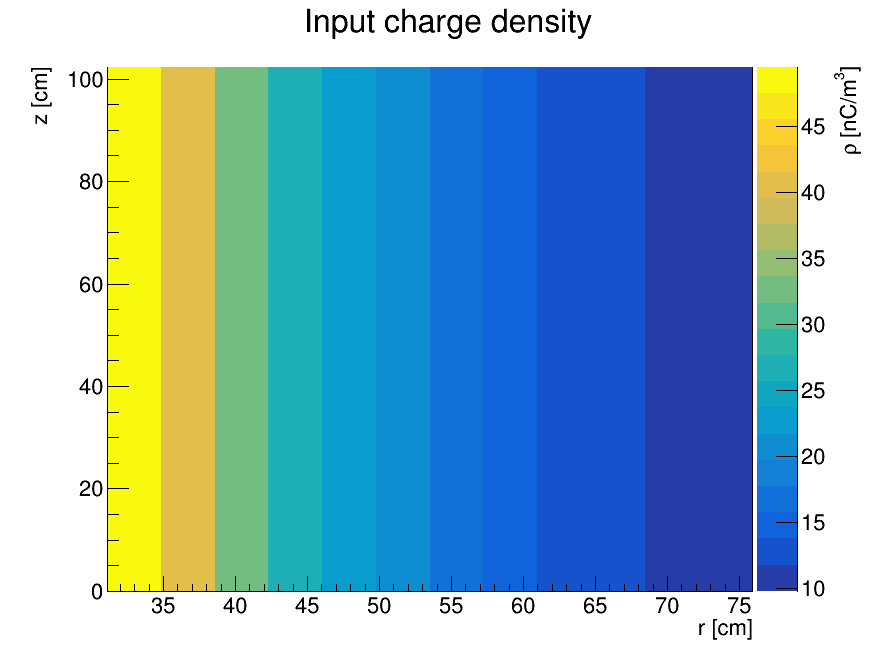

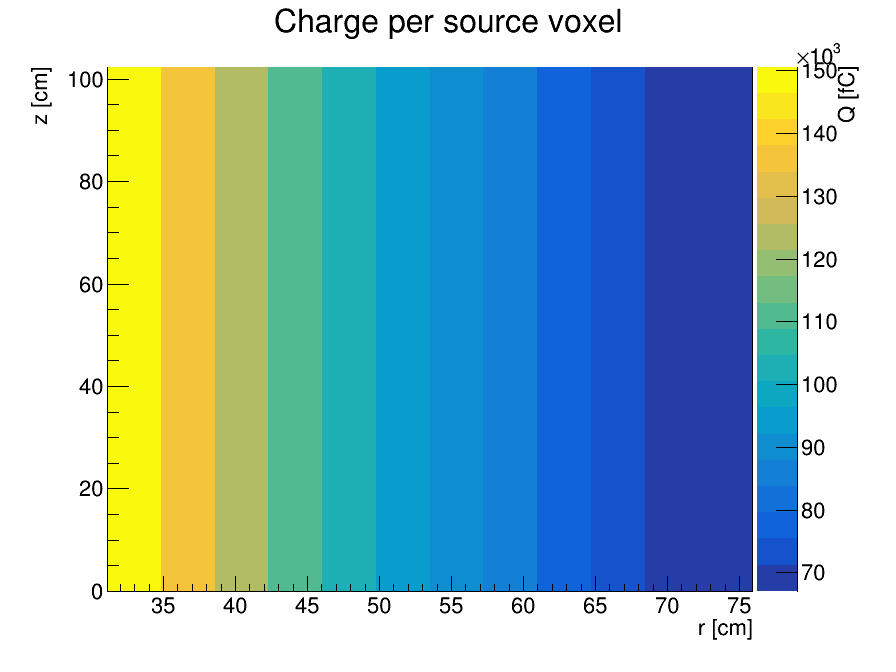

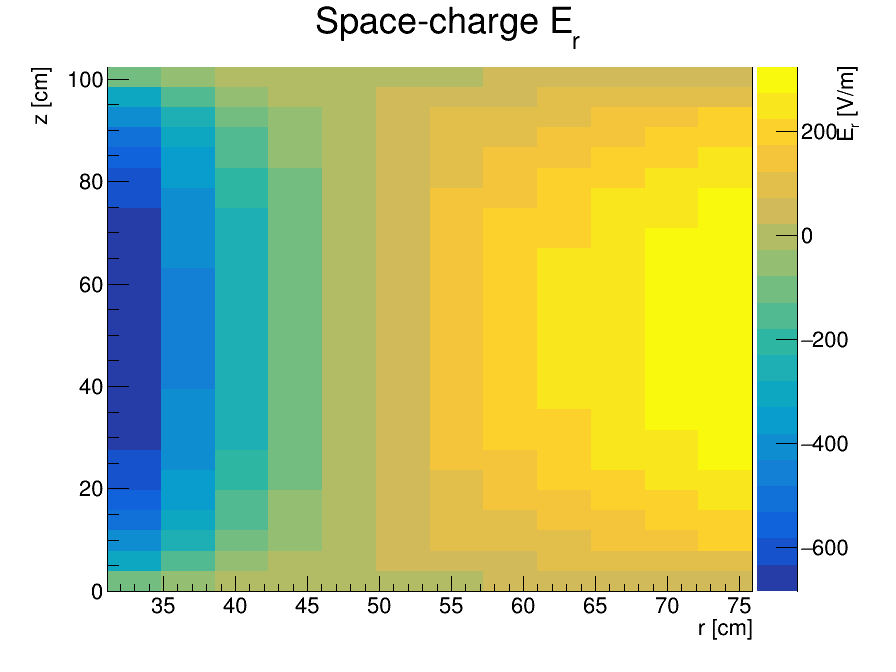

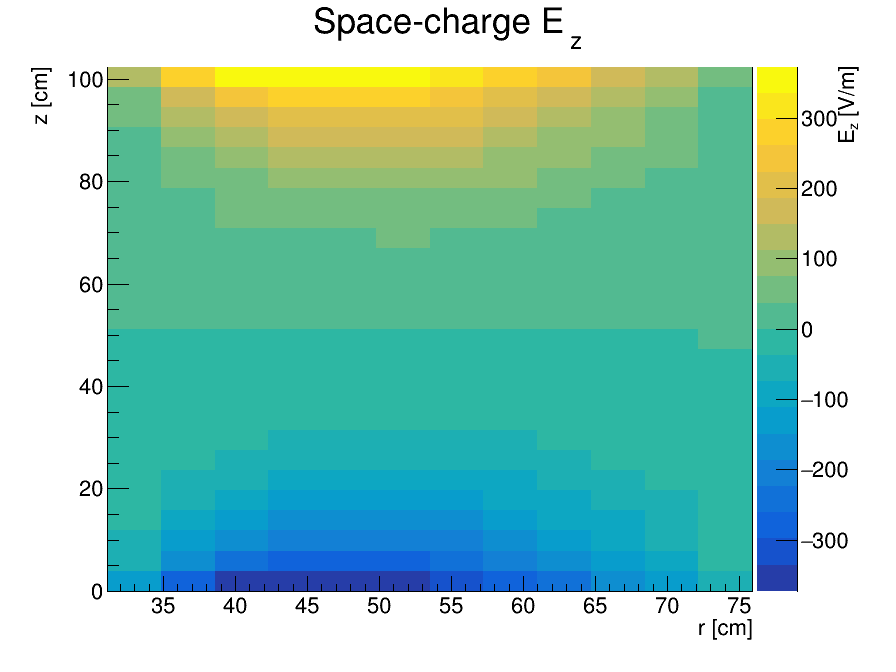

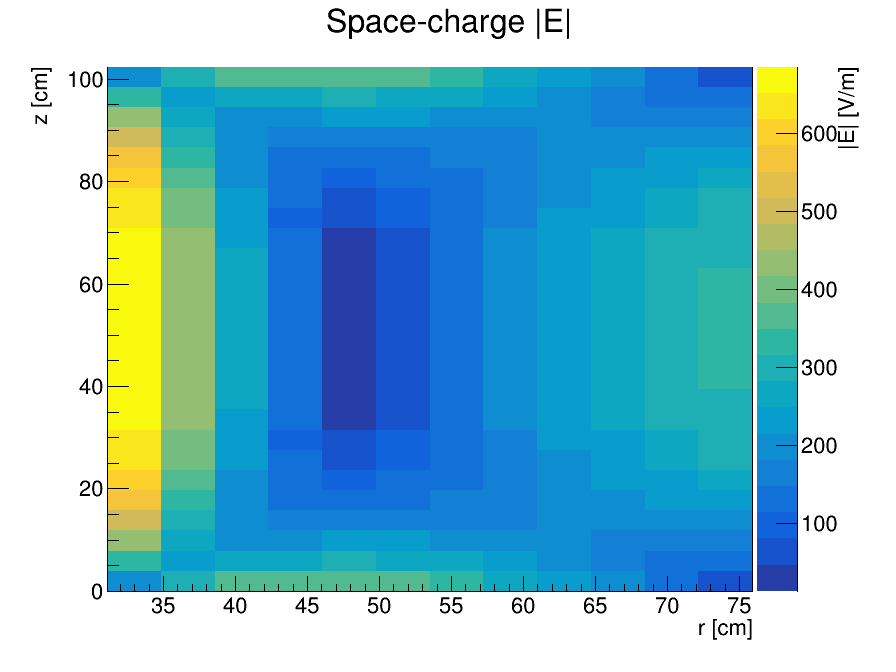

Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_charge_density.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_charge_per_voxel.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_Er_default.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_Ez_default.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_Emag_default.png has been created


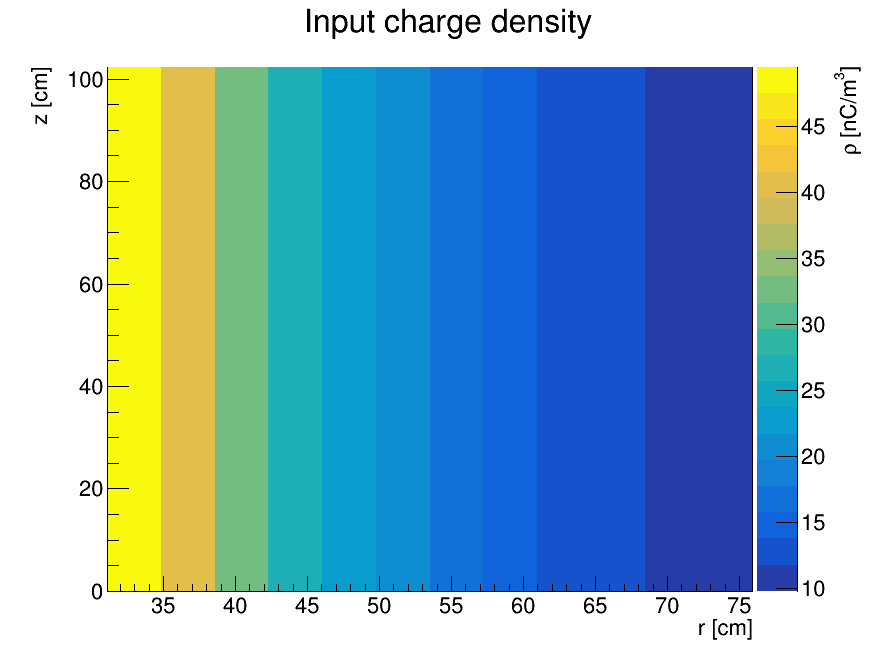

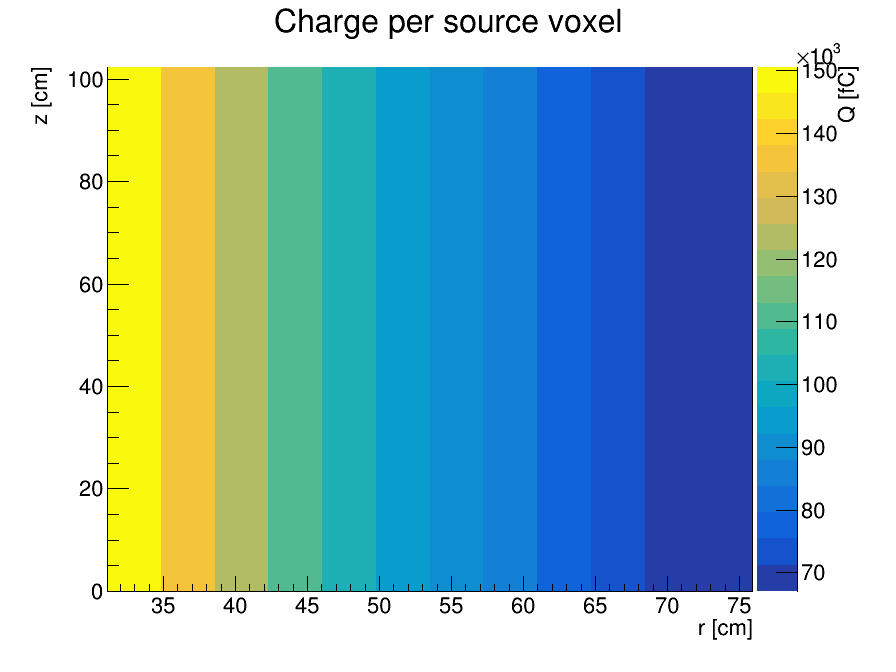

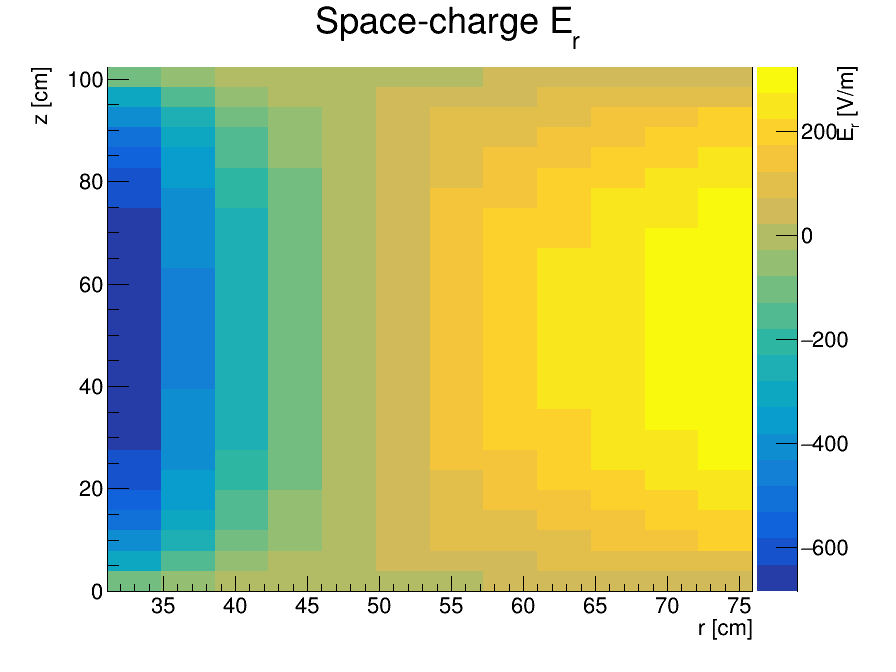

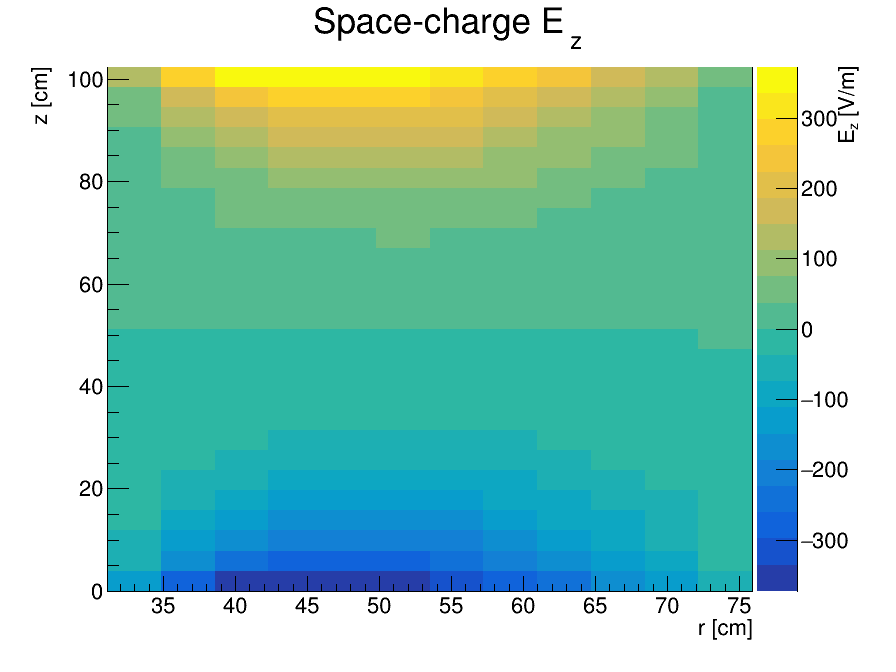

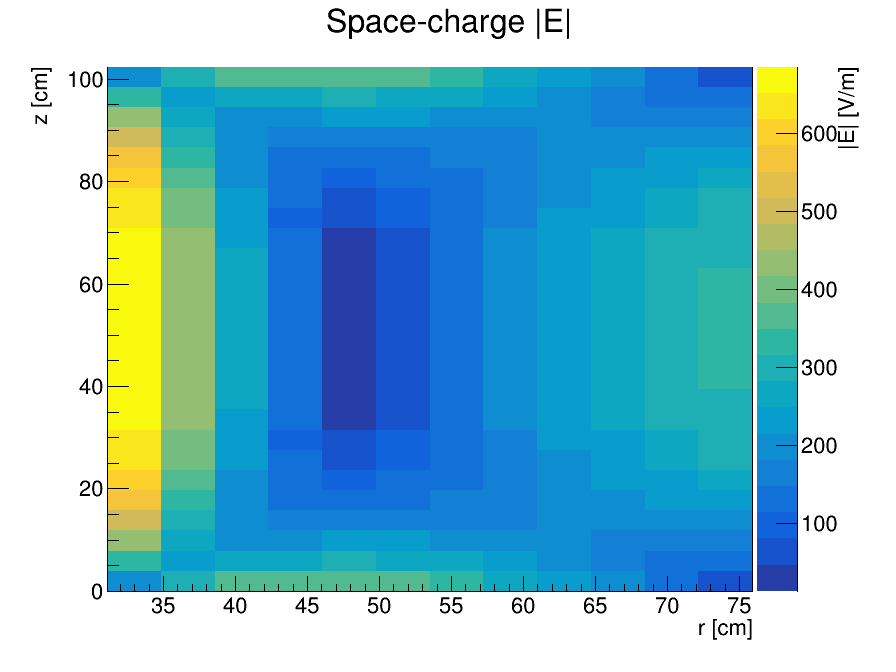

In [ ]:
def draw_th2(canvas_name, hist, option="COLZ", logz=False,
             width=900, height=700, right_margin=0.16):
    c = root.TCanvas(canvas_name, canvas_name, width, height)
    c.SetRightMargin(right_margin)
    c.SetLeftMargin(0.12)
    c.SetBottomMargin(0.12)
    c.SetLogz(logz)
    hist.SetStats(False)
    hist.Draw(option)
    c.Update()

    if SAVE_QA_PNG:
        png = str(Path(QA_PLOT_DIRECTORY) / f"{canvas_name}.png")
        c.SaveAs(png)
        if DISPLAY_QA_PLOTS_INLINE:
            display(Image(filename=png))
    return c

qa_canvases = []

if DO_QA:
    plot_map = {
        "qa_charge_density": qa_objects[0],
        "qa_charge_per_voxel": qa_objects[1],
        "qa_Er_default": qa_objects[2],
        "qa_Ez_default": qa_objects[3],
        "qa_Emag_default": qa_objects[4],
    }

    for cname, hist in plot_map.items():
        qa_canvases.append(draw_th2(cname, hist))

## 10. Radial profiles and mean field summaries

Two-dimensional maps are essential, but one-dimensional summaries make trends and sign changes easier to inspect.

For each radius, define the longitudinal mean

$$
\langle E_r\rangle_z(r)
=
\frac{1}{L}
\int_0^L E_r(r,z)\,dz,
$$

and similarly for $E_z$ and $|\delta\mathbf E|$.

The notebook also plots radial profiles at several longitudinal positions: close to the central membrane, near the middle of the drift volume, and close to the readout plane.

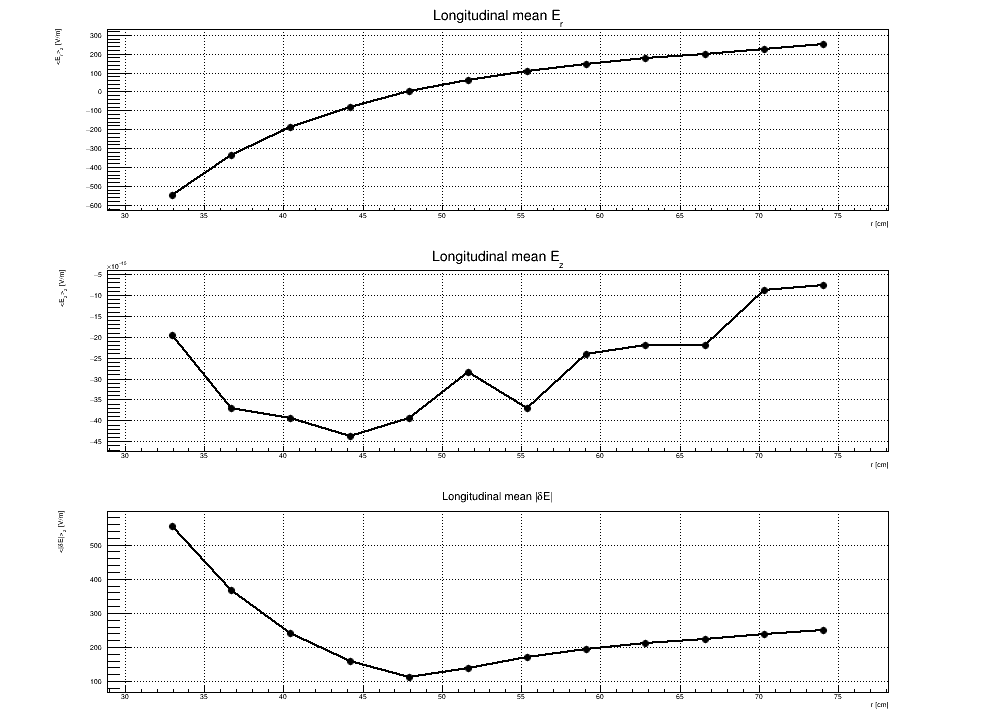

TypeError: none of the 12 overloaded methods succeeded. Full details:
  TGraph::TGraph(const TGraph& gr) =>
    TypeError: takes at most 1 arguments (3 given)
  TGraph::TGraph(const TVectorT<float>& vx, const TVectorT<float>& vy) =>
    TypeError: takes at most 2 arguments (3 given)
  TGraph::TGraph(const TVectorT<double>& vx, const TVectorT<double>& vy) =>
    TypeError: takes at most 2 arguments (3 given)
  TGraph::TGraph(const TH1* h) =>
    TypeError: takes at most 1 arguments (3 given)
  TGraph::TGraph(const TF1* f, const char* option = "") =>
    TypeError: takes at most 2 arguments (3 given)
  TGraph::TGraph() =>
    TypeError: takes at most 0 arguments (3 given)
  TGraph::TGraph(int n) =>
    TypeError: takes at most 1 arguments (3 given)
  TGraph::TGraph(const char* filename, const char* format = "%lg %lg", const char* option = "") =>
    TypeError: could not convert argument 1 (bad argument type for built-in operation)
  TGraph::TGraph(int n, const double* y, double start = 0

Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_mean_fields_vs_r.png has been created


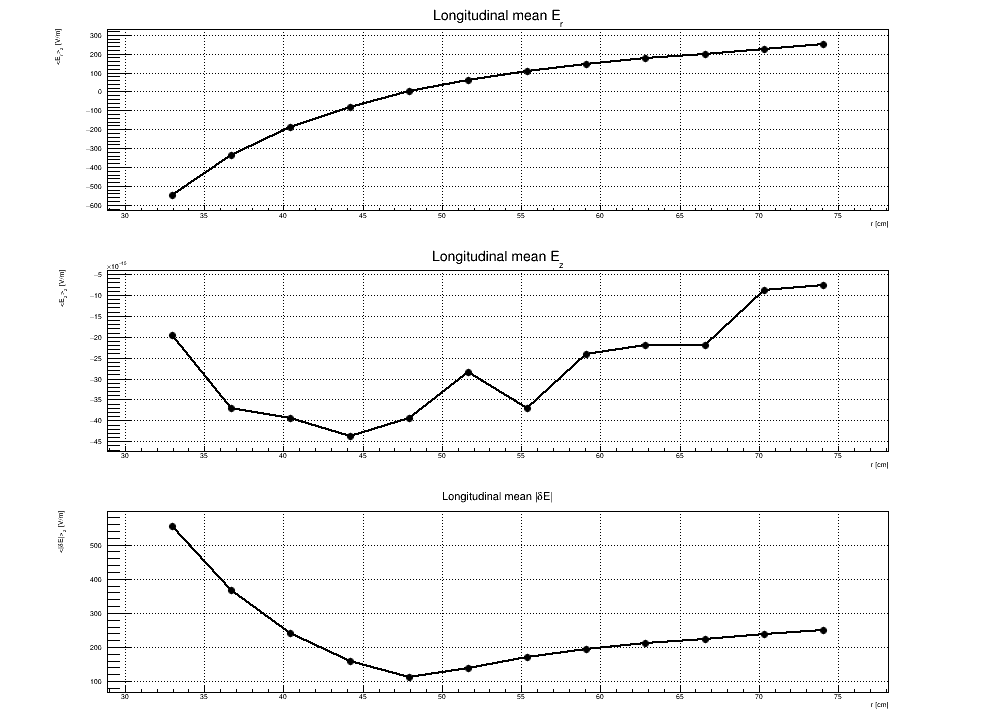

In [ ]:
def make_tgraph(x, y, name, title, xtitle, ytitle):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    g = root.TGraph(len(x), x, y)
    g.SetName(name)
    g.SetTitle(title)
    g.GetXaxis().SetTitle(xtitle)
    g.GetYaxis().SetTitle(ytitle)
    g.SetLineWidth(2)
    g.SetMarkerStyle(20)
    g.SetMarkerSize(0.8)
    return g

if DO_QA:
    mean_Er_r = np.mean(E_r_grid, axis=1)
    mean_Ez_r = np.mean(E_z_grid, axis=1)
    mean_Emag_r = np.mean(E_mag_grid, axis=1)

    g_mean_Er = make_tgraph(
        100*r_centers, mean_Er_r,
        "gMeanErVsR", "Longitudinal mean E_{r}",
        "r [cm]", "<E_{r}>_{z} [V/m]"
    )
    g_mean_Ez = make_tgraph(
        100*r_centers, mean_Ez_r,
        "gMeanEzVsR", "Longitudinal mean E_{z}",
        "r [cm]", "<E_{z}>_{z} [V/m]"
    )
    g_mean_Emag = make_tgraph(
        100*r_centers, mean_Emag_r,
        "gMeanEmagVsR", "Longitudinal mean |#deltaE|",
        "r [cm]", "<|#deltaE|>_{z} [V/m]"
    )

    c_mean_fields = root.TCanvas("qa_mean_fields_vs_r", "", 1000, 750)
    c_mean_fields.Divide(1, 3)
    for ipad, graph in enumerate([g_mean_Er, g_mean_Ez, g_mean_Emag], start=1):
        c_mean_fields.cd(ipad)
        root.gPad.SetGrid()
        graph.Draw("ALP")
    c_mean_fields.Update()

    png = str(Path(QA_PLOT_DIRECTORY) / "qa_mean_fields_vs_r.png")
    if SAVE_QA_PNG:
        c_mean_fields.SaveAs(png)
        if DISPLAY_QA_PLOTS_INLINE:
            display(Image(filename=png))

    # Radial Er profiles at representative z values.
    z_indices = sorted(set([0, nz//4, nz//2, 3*nz//4, nz-1]))
    c_er_slices = root.TCanvas("qa_Er_radial_slices", "", 1000, 750)
    c_er_slices.SetGrid()
    mg = root.TMultiGraph()
    legend = root.TLegend(0.66, 0.62, 0.88, 0.88)

    for iline, iz in enumerate(z_indices):
        x_vals = np.ascontiguousarray(100 * r_centers, dtype=np.float64)
        y_vals = np.ascontiguousarray(E_r_grid[:, iz], dtype=np.float64)
        g = make_tgraph(
            100*r_centers, E_r_grid[:, iz],
            f"gEr_z{iz}", "", "r [cm]", "E_{r} [V/m]"
        )
        g.SetLineColor(iline + 1)
        g.SetMarkerColor(iline + 1)
        mg.Add(g, "LP")
        legend.AddEntry(g, f"z = {100*z_centers[iz]:.1f} cm", "lp")

    mg.SetTitle("Radial electric-field profiles; r [cm]; E_{r} [V/m]")
    mg.Draw("A")
    legend.Draw()
    c_er_slices.Update()

    png = str(Path(QA_PLOT_DIRECTORY) / "qa_Er_radial_slices.png")
    if SAVE_QA_PNG:
        c_er_slices.SaveAs(png)
        if DISPLAY_QA_PLOTS_INLINE:
            display(Image(filename=png))

    qa_objects += [g_mean_Er, g_mean_Ez, g_mean_Emag]
    qa_canvases += [c_mean_fields, c_er_slices]

## 11. First-order distortion estimate

The electrostatic solution gives $\delta E_r$ and $\delta E_z$, but the quantity relevant for tracking is the electron displacement accumulated during the drift.

For a nominal field $E_0\hat z$, an axisymmetric perturbation with $E_\phi=0$, and a uniform magnetic field parallel to the drift field, the first-order transverse response can be written as

$$
C_0=\frac{1}{1+(\omega\tau)^2},
\qquad
C_1=\frac{\omega\tau}{1+(\omega\tau)^2}.
$$

To first order,

$$
\frac{dr}{dz}
\approx
C_0\frac{E_r}{E_0+\delta E_z},
$$

and

$$
\frac{d(r\phi)}{dz}
\approx
-C_1\frac{E_r}{E_0+\delta E_z}.
$$

Thus an axisymmetric radial electric field can generate both radial and azimuthal displacement. The magnetic field suppresses the radial response and rotates part of it into the azimuthal direction.

The present calculation is a **provisional QA estimate**, controlled by `OMEGA_TAU` and `NOMINAL_DRIFT_FIELD_V_PER_CM`. It is not yet a substitute for Magboltz transport coefficients or the final sPHENIX distortion integrator.

For a point created at $(r,z)$, the displacement is integrated from that point to the readout plane at $z=L$:

$$
\Delta r(r,z)
=
\int_z^L
C_0\frac{E_r(r,z')}{E_0+\delta E_z(r,z')}\,dz',
$$

$$
\Delta(r\phi)(r,z)
=
-\int_z^L
C_1\frac{E_r(r,z')}{E_0+\delta E_z(r,z')}\,dz'.
$$

In [ ]:
def cumulative_integral_to_readout(values, z):
    values = np.asarray(values, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)
    out = np.zeros_like(values)

    # Integrate backward from the readout plane using trapezoids.
    for j in range(len(z)-2, -1, -1):
        dz_local = z[j+1] - z[j]
        out[j] = out[j+1] + 0.5*dz_local*(values[j+1] + values[j])
    return out

E0_V_PER_M = NOMINAL_DRIFT_FIELD_V_PER_CM * 100.0
C0 = 1.0 / (1.0 + OMEGA_TAU**2)
C1 = OMEGA_TAU / (1.0 + OMEGA_TAU**2)

denominator = E0_V_PER_M + E_z_grid
if np.any(np.abs(denominator) < 0.1*abs(E0_V_PER_M)):
    raise RuntimeError(
        "The perturbation field locally makes the effective longitudinal "
        "field too small for the first-order distortion approximation."
    )

dr_dz = C0 * E_r_grid / denominator
rdphi_dz = -C1 * E_r_grid / denominator

delta_r = np.zeros_like(E_r_grid)
delta_rphi = np.zeros_like(E_r_grid)

for ir in range(nr):
    delta_r[ir, :] = cumulative_integral_to_readout(
        dr_dz[ir, :], z_centers
    )
    delta_rphi[ir, :] = cumulative_integral_to_readout(
        rdphi_dz[ir, :], z_centers
    )

delta_r_mm = delta_r * 1000.0
delta_rphi_mm = delta_rphi * 1000.0
delta_transverse_mm = np.hypot(delta_r_mm, delta_rphi_mm)

print(f"C0 = {C0:.6f}")
print(f"C1 = {C1:.6f}")
print(f"max |Delta r| = {np.max(np.abs(delta_r_mm)):.6f} mm")
print(f"max |Delta(r phi)| = {np.max(np.abs(delta_rphi_mm)):.6f} mm")

C0 = 0.158983
C1 = 0.365660
max |Delta r| = 1.915406 mm
max |Delta(r phi)| = 4.405433 mm


### Distortion QA plots

The two-dimensional maps show where electrons created in the drift volume are displaced most strongly.

The radial summary

$$
\langle\Delta r\rangle_z(r)
=
\frac{1}{N_z}\sum_j\Delta r(r,z_j)
$$

is useful for direct comparison with the radial-shape plots in the sPHENIX space-charge slides. The maximum-over-$z$ curve is also shown because the mean can hide sign changes.

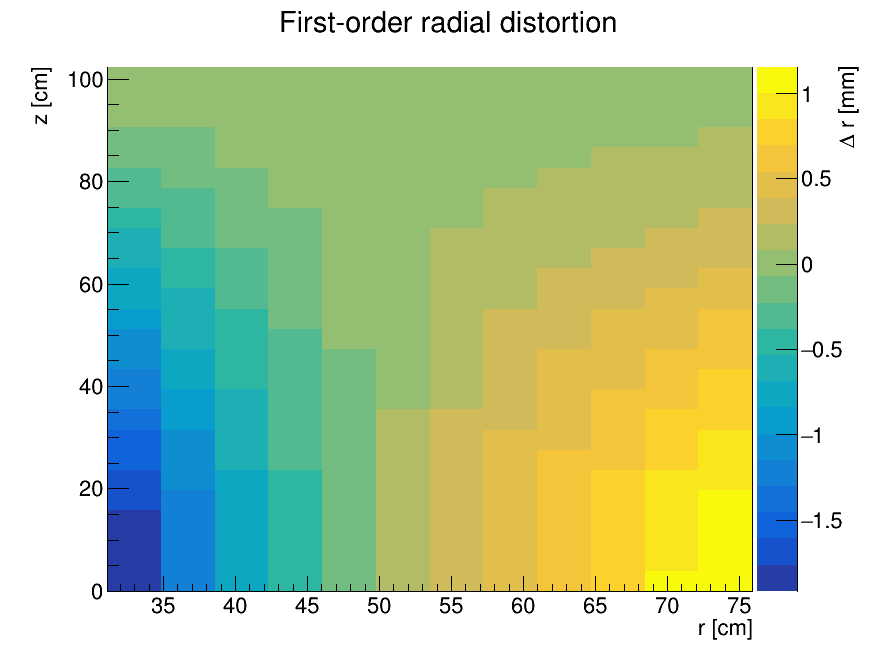

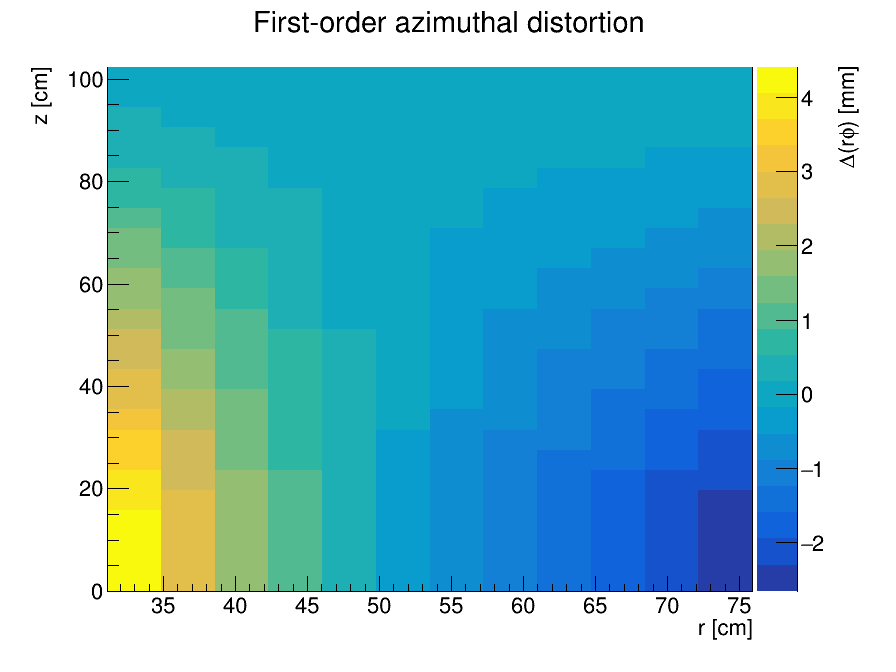

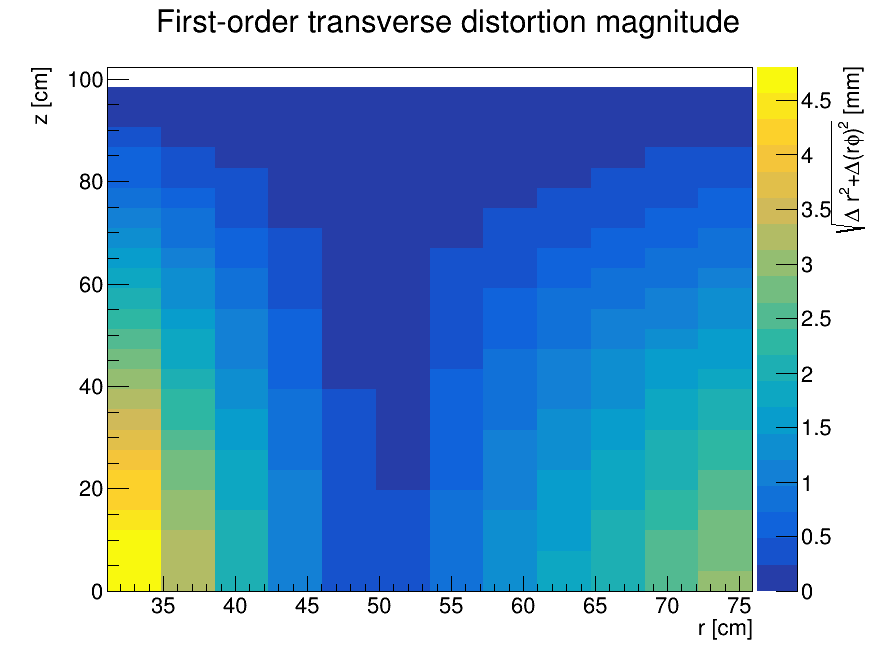

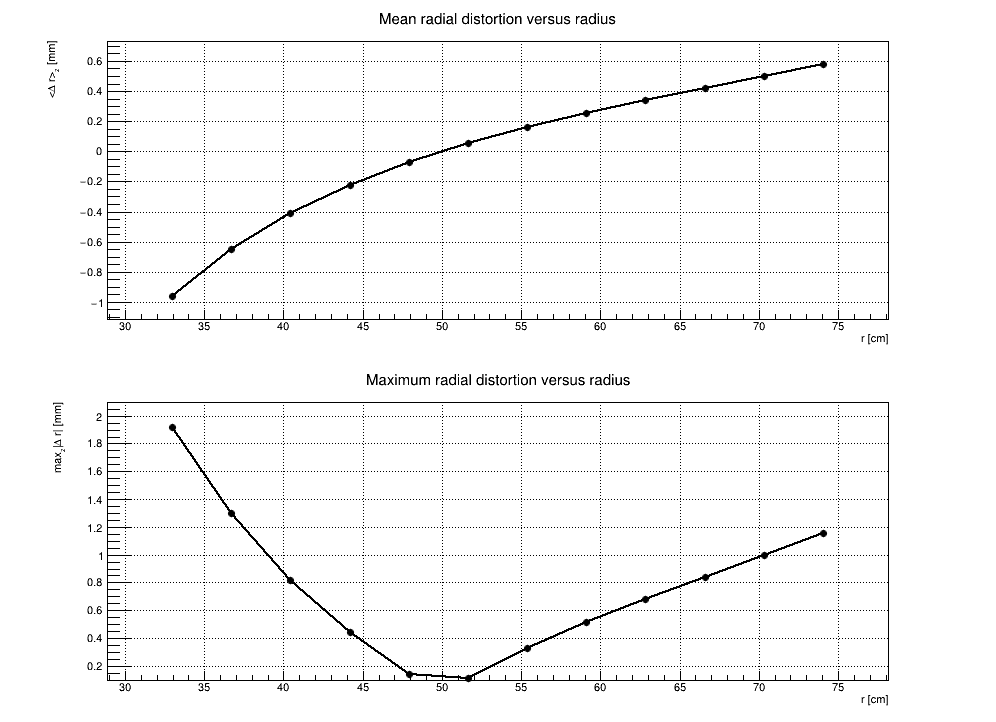

Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_delta_r_map.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_delta_rphi_map.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_delta_transverse_map.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_delta_r_summary.png has been created


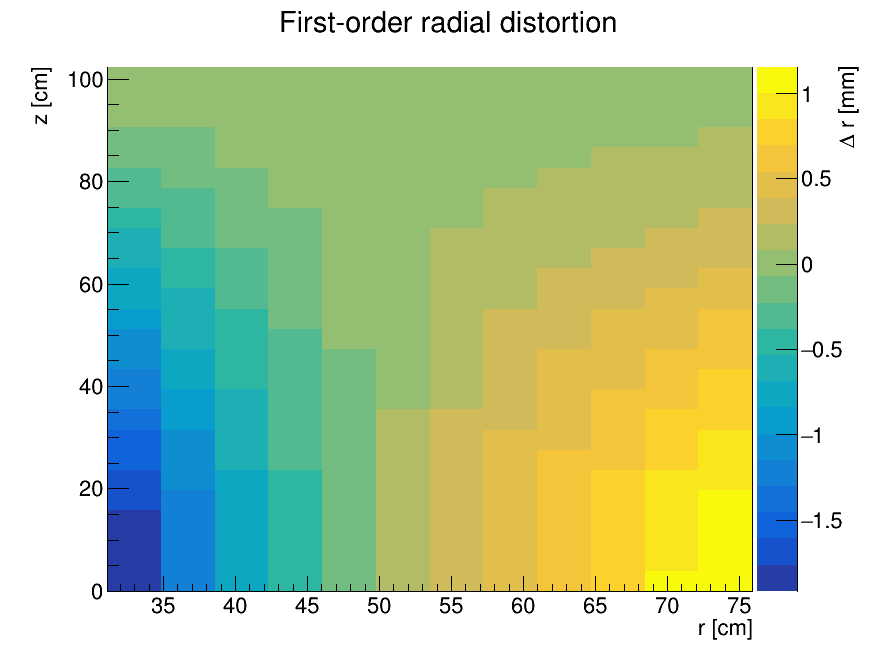

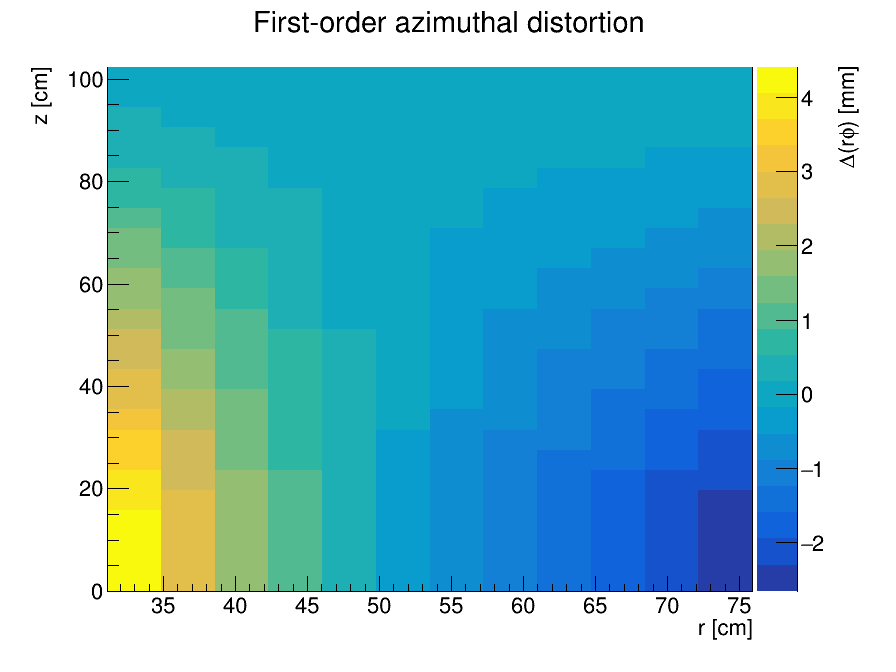

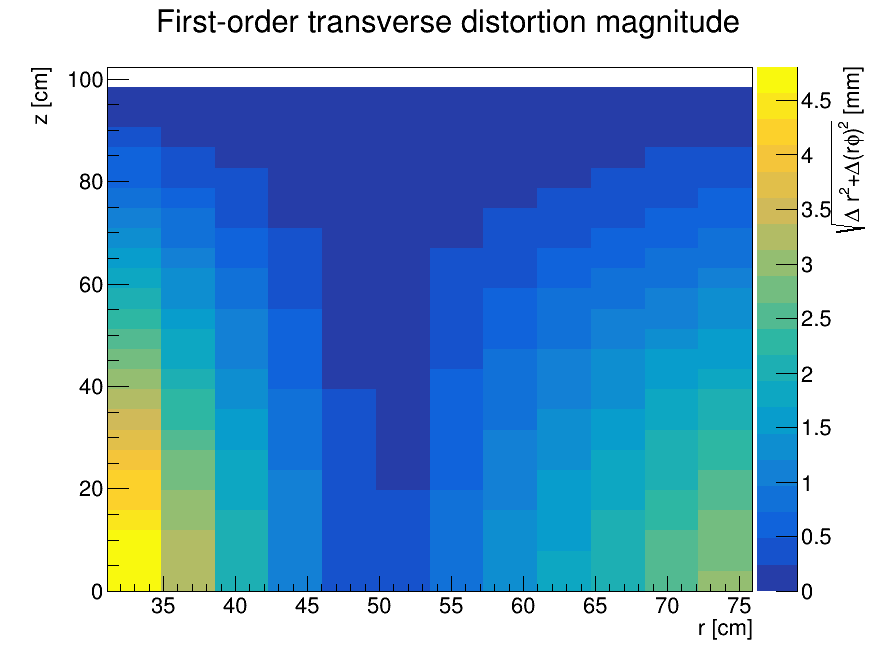

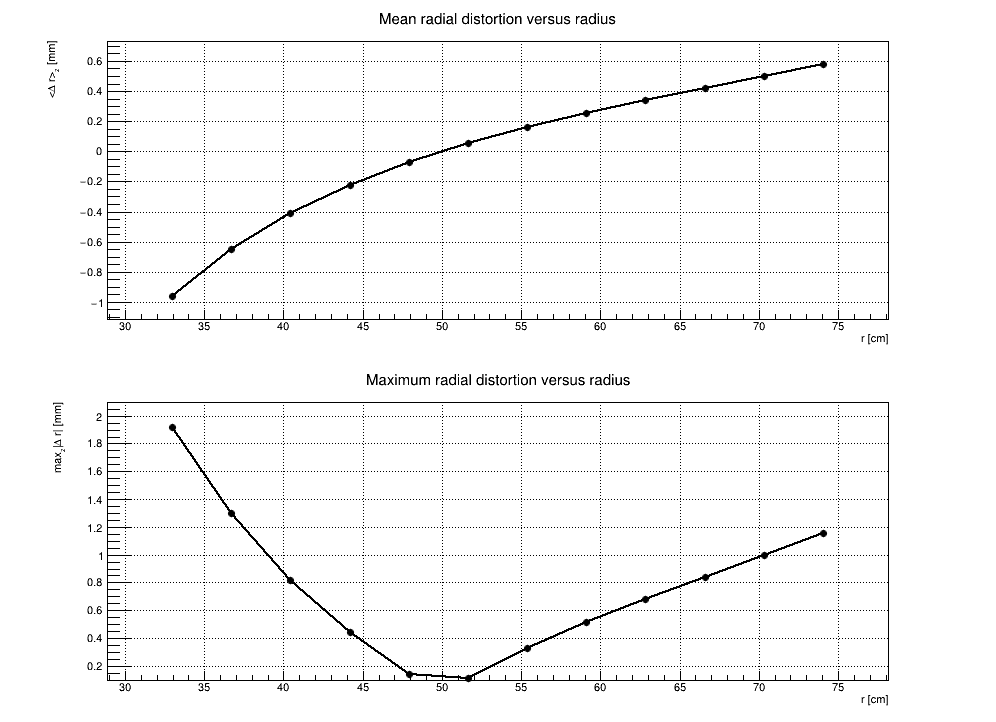

In [ ]:
if DO_QA:
    h_dr = numpy_to_th2(
        "hDeltaR",
        "First-order radial distortion; r [cm]; z [cm]",
        delta_r_mm, r_edges, z_edges,
        "#Delta r [mm]"
    )
    h_rdphi = numpy_to_th2(
        "hDeltaRPhi",
        "First-order azimuthal distortion; r [cm]; z [cm]",
        delta_rphi_mm, r_edges, z_edges,
        "#Delta(r#phi) [mm]"
    )
    h_dtrans = numpy_to_th2(
        "hDeltaTransverse",
        "First-order transverse distortion magnitude; r [cm]; z [cm]",
        delta_transverse_mm, r_edges, z_edges,
        "#sqrt{#Delta r^{2}+#Delta(r#phi)^{2}} [mm]"
    )

    qa_objects += [h_dr, h_rdphi, h_dtrans]

    qa_canvases += [
        draw_th2("qa_delta_r_map", h_dr),
        draw_th2("qa_delta_rphi_map", h_rdphi),
        draw_th2("qa_delta_transverse_map", h_dtrans),
    ]

    mean_dr = np.mean(delta_r_mm, axis=1)
    maxabs_dr = np.max(np.abs(delta_r_mm), axis=1)

    g_mean_dr = make_tgraph(
        100*r_centers, mean_dr,
        "gMeanDeltaRVsR",
        "Mean radial distortion versus radius",
        "r [cm]", "<#Delta r>_{z} [mm]"
    )
    g_max_dr = make_tgraph(
        100*r_centers, maxabs_dr,
        "gMaxAbsDeltaRVsR",
        "Maximum radial distortion versus radius",
        "r [cm]", "max_{z}|#Delta r| [mm]"
    )

    c_dr_summary = root.TCanvas("qa_delta_r_summary", "", 1000, 750)
    c_dr_summary.Divide(1, 2)
    c_dr_summary.cd(1)
    root.gPad.SetGrid()
    g_mean_dr.Draw("ALP")
    c_dr_summary.cd(2)
    root.gPad.SetGrid()
    g_max_dr.Draw("ALP")
    c_dr_summary.Update()

    png = str(Path(QA_PLOT_DIRECTORY) / "qa_delta_r_summary.png")
    if SAVE_QA_PNG:
        c_dr_summary.SaveAs(png)
        if DISPLAY_QA_PLOTS_INLINE:
            display(Image(filename=png))

    qa_objects += [g_mean_dr, g_max_dr]
    qa_canvases.append(c_dr_summary)

## 12. Single-source response maps

A kernel is easier to debug by examining representative source voxels than by inspecting the full four-dimensional matrix.

The automatic selection covers:

- near the inner field cage;
- middle radius;
- near the outer field cage;
- near the central membrane;
- middle drift;
- near the readout plane.

For each selected source voxel, the notebook stores $K_r(r,z;r',z')$ and $K_z(r,z;r',z')$.

In [ ]:
def representative_source_indices():
    ir_choices = sorted(set([0, nr//2, nr-1]))
    iz_choices = sorted(set([0, nz//2, nz-1]))
    pairs = []
    for ir in ir_choices:
        for iz in iz_choices:
            pairs.append((ir, iz))
    # Prefer a compact subset spanning the domain
    preferred = [
        (0, 0), (0, nz//2),
        (nr//2, nz//2),
        (nr-1, nz//2), (nr-1, nz-1),
        (nr//2, 0)
    ]
    out = []
    for p in preferred + pairs:
        if p not in out:
            out.append(p)
        if len(out) >= MAX_QA_SOURCES:
            break
    return out

if QA_SOURCE_INDICES is None:
    QA_SOURCE_INDICES = representative_source_indices()

if DO_QA:
    for irs, izs in QA_SOURCE_INDICES:
        q = irs*nz + izs
        kr_map = K_r[:, q].reshape(nr, nz)
        kz_map = K_z[:, q].reshape(nr, nz)
        tag = f"src_r{irs}_z{izs}"
        title_pos = (
            f"r'={100*r_centers[irs]:.2f} cm, "
            f"z'={100*z_centers[izs]:.2f} cm"
        )
        qa_objects += [
            numpy_to_th2(
                f"hKr_{tag}",
                f"K_{{r}} for {title_pos}; r [cm]; z [cm]",
                kr_map, r_edges, z_edges,
                "K_{r} [(V/m)/C]"
            ),
            numpy_to_th2(
                f"hKz_{tag}",
                f"K_{{z}} for {title_pos}; r [cm]; z [cm]",
                kz_map, r_edges, z_edges,
                "K_{z} [(V/m)/C]"
            )
        ]

## 13. Symmetry QA

With identical Dirichlet conditions at $z=0$ and $z=L$, simultaneous reflection of source and observation coordinates gives

$$
K_r(r,L-z;r',L-z')=K_r(r,z;r',z'),
$$

$$
K_z(r,L-z;r',L-z')=-K_z(r,z;r',z').
$$

These tests are sensitive to flattening-index mistakes, sign errors in $E_z$, and incorrect source-cell integration.

In [ ]:
if DO_QA:
    K_r_4d = K_r.reshape(nr, nz, nr, nz)
    K_z_4d = K_z.reshape(nr, nz, nr, nz)

    Kr_reflected = K_r_4d[:, ::-1, :, ::-1]
    Kz_reflected = K_z_4d[:, ::-1, :, ::-1]

    kr_scale = np.maximum(np.abs(K_r_4d), np.max(np.abs(K_r_4d))*1e-12)
    kz_scale = np.maximum(np.abs(K_z_4d), np.max(np.abs(K_z_4d))*1e-12)

    kr_rel = np.abs(K_r_4d - Kr_reflected) / kr_scale
    kz_rel = np.abs(K_z_4d + Kz_reflected) / kz_scale

    print("Reflection QA:")
    print("  max relative Kr even-symmetry residual =", np.max(kr_rel))
    print("  max relative Kz odd-symmetry residual  =", np.max(kz_rel))

Reflection QA:
  max relative Kr even-symmetry residual = 2.606470320743107e-09
  max relative Kz odd-symmetry residual  = 5.168573036841024e-10


## 14. Evaluate one source at arbitrary coordinates

The Gauss-law test and convergence studies require the field away from the observation-cell centers. The next helper evaluates the modal expansion at arbitrary arrays of $r$ and $z$ for one finite source voxel.

No interpolation of the coarse kernel is used in the Gauss test; the field is evaluated directly from the eigenmode coefficients.

In [ ]:
def source_modal_coefficients(ir_src, iz_src, nrad=None, nlong=None):
    if nrad is None:
        nrad = N_RADIAL_MODES
    if nlong is None:
        nlong = N_LONGITUDINAL_MODES

    qsrc = ir_src*nz + iz_src
    S = source_projection[qsrc, :].reshape(
        N_RADIAL_MODES, N_LONGITUDINAL_MODES
    )
    coeff = S[:nrad, :nlong] / normalization_nm[:nrad, :nlong]
    return coeff

def evaluate_source_field(ir_src, iz_src, r_points, z_points,
                          source_charge_c=1.0,
                          nrad=None, nlong=None):
    if nrad is None:
        nrad = N_RADIAL_MODES
    if nlong is None:
        nlong = N_LONGITUDINAL_MODES

    r_points = np.asarray(r_points, dtype=np.float64)
    z_points = np.asarray(z_points, dtype=np.float64)
    r_points, z_points = np.broadcast_arrays(r_points, z_points)

    coeff = source_modal_coefficients(
        ir_src, iz_src, nrad=nrad, nlong=nlong
    ) * source_charge_c

    Er = np.zeros(r_points.size)
    Ez = np.zeros(r_points.size)

    rf = r_points.ravel()
    zf = z_points.ravel()

    for i, (rr, zz) in enumerate(zip(rf, zf)):
        R = np.array([radial_basis(k, rr) for k in k_modes[:nrad]])
        dR = np.array([
            radial_basis_derivative(k, rr) for k in k_modes[:nrad]
        ])
        s = np.sin(q_modes[:nlong] * zz)
        c = np.cos(q_modes[:nlong] * zz)

        Er[i] = np.sum(-coeff * np.outer(dR, s))
        Ez[i] = np.sum(
            -coeff * np.outer(R, q_modes[:nlong] * c)
        )

    return Er.reshape(r_points.shape), Ez.reshape(r_points.shape)

## 15. Mode-convergence QA

A truncated eigenfunction expansion must be checked at representative points. Convergence is usually slowest close to the source-cell boundaries and near the singular point-source limit.

For each test configuration, the notebook compares partial sums as the number of radial and longitudinal modes is increased. The finite source voxel should make the sequence substantially more stable than a point-source expansion.

In [ ]:
def convergence_scan(ir_src, iz_src, r_obs, z_obs):
    nrad_values = sorted(set(
        [4, 6, 8, 12, 16, 24, N_RADIAL_MODES]
    ))
    nrad_values = [n for n in nrad_values if n <= N_RADIAL_MODES]

    nlong_values = sorted(set(
        [4, 6, 8, 12, 16, 24, 32, N_LONGITUDINAL_MODES]
    ))
    nlong_values = [n for n in nlong_values if n <= N_LONGITUDINAL_MODES]

    radial_scan = []
    for nrad in nrad_values:
        er, ez = evaluate_source_field(
            ir_src, iz_src, r_obs, z_obs,
            nrad=nrad, nlong=N_LONGITUDINAL_MODES
        )
        radial_scan.append((nrad, float(er), float(ez)))

    longitudinal_scan = []
    for nlong in nlong_values:
        er, ez = evaluate_source_field(
            ir_src, iz_src, r_obs, z_obs,
            nrad=N_RADIAL_MODES, nlong=nlong
        )
        longitudinal_scan.append((nlong, float(er), float(ez)))

    return radial_scan, longitudinal_scan

convergence_results = {}

if DO_QA:
    irs, izs = nr//2, nz//2

    # One point separated from source and one neighboring point.
    test_points = {
        "separated": (r_centers[min(nr-1, irs+3)],
                      z_centers[min(nz-1, izs+3)]),
        "near_source": (r_centers[min(nr-1, irs+1)],
                        z_centers[izs])
    }

    for name, (ro, zo) in test_points.items():
        rs, zs = convergence_scan(irs, izs, ro, zo)
        convergence_results[name] = {"radial": rs, "longitudinal": zs}
        print(f"\nConvergence point '{name}': r={100*ro:.2f} cm, z={100*zo:.2f} cm")
        print(" radial modes: last result", rs[-1])
        print(" longitudinal modes: last result", zs[-1])


Convergence point 'separated': r=66.58 cm, z=64.94 cm
 radial modes: last result (36, 27623077158.224773, 15322955083.644777)
 longitudinal modes: last result (48, 27623077158.224773, 15322955083.644777)

Convergence point 'near_source': r=59.11 cm, z=53.13 cm
 radial modes: last result (36, 136617973098.83017, 31323363.09671758)
 longitudinal modes: last result (48, 136617973098.83017, 31323363.09671758)


## 16. Gauss-law test

For an axisymmetric rectangular contour in the $r-z$ plane, the corresponding three-dimensional Gaussian surface is a closed annular cylinder.

For boundaries $r_1,r_2,z_1,z_2$, the outward electric flux is

$$
\begin{aligned}
\Phi_E ={}&
2\pi r_2\int_{z_1}^{z_2}E_r(r_2,z)\,dz
-
2\pi r_1\int_{z_1}^{z_2}E_r(r_1,z)\,dz\\
&+
2\pi\int_{r_1}^{r_2}rE_z(r,z_2)\,dr
-
2\pi\int_{r_1}^{r_2}rE_z(r,z_1)\,dr.
\end{aligned}
$$

Gauss's law requires

$$
G\equiv\frac{\epsilon_0\Phi_E}{Q_{\rm source}}
=
\begin{cases}
1,&\text{source fully enclosed},\\
0,&\text{source excluded}.
\end{cases}
$$

If the Gaussian surface cuts through the finite source voxel, an intermediate enclosed-charge fraction is expected. The field is evaluated directly from the eigenmode expansion on high-order quadrature points.

Gauss-law test:
  fully enclosed: epsilon0*flux/Q = 1.00110984
  excluded      : epsilon0*flux/Q = 0.00000599


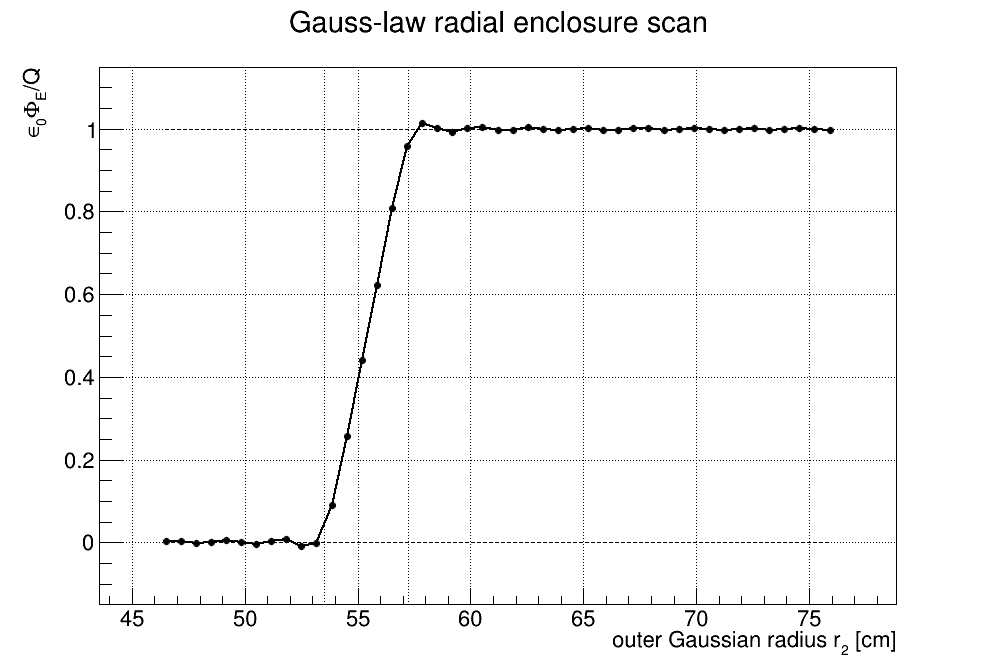

Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_gauss_radial_scan.png has been created


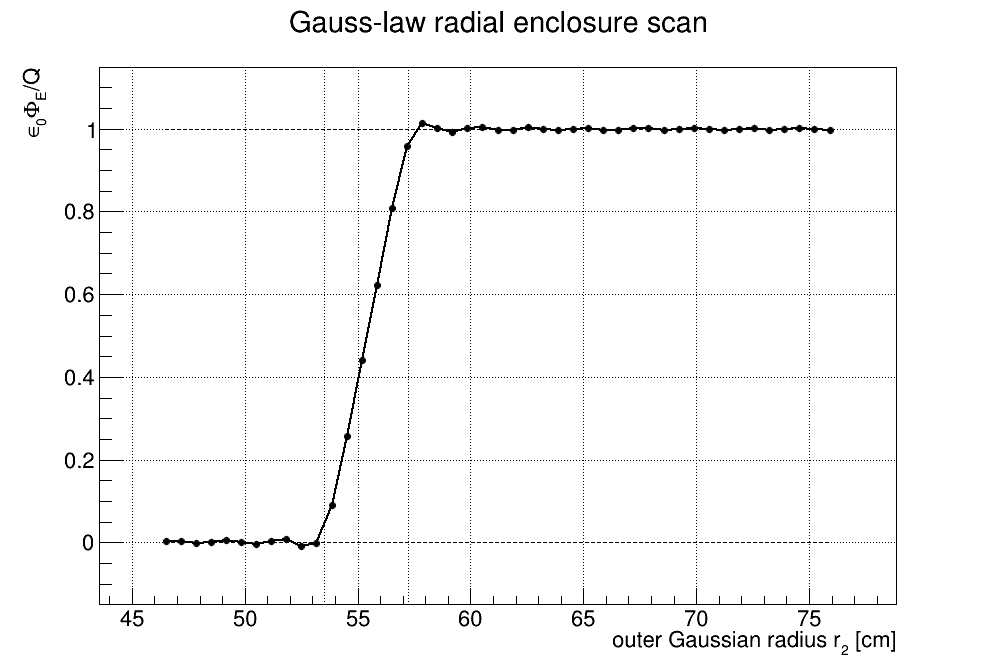

In [ ]:
def gauss_flux_for_source(ir_src, iz_src, r1, r2, z1, z2,
                          source_charge_c=1.0,
                          quad_order=GAUSS_QUADRATURE_ORDER):
    xg, wg = leggauss(quad_order)

    # z integration on radial walls
    zq = 0.5*(z2-z1)*xg + 0.5*(z2+z1)
    wz = 0.5*(z2-z1)*wg

    er_r2, _ = evaluate_source_field(
        ir_src, iz_src, np.full_like(zq, r2), zq,
        source_charge_c=source_charge_c
    )
    er_r1, _ = evaluate_source_field(
        ir_src, iz_src, np.full_like(zq, r1), zq,
        source_charge_c=source_charge_c
    )

    flux_radial = (
        2*np.pi*r2*np.sum(wz*er_r2)
        -2*np.pi*r1*np.sum(wz*er_r1)
    )

    # r integration on z caps
    rq = 0.5*(r2-r1)*xg + 0.5*(r2+r1)
    wr = 0.5*(r2-r1)*wg

    _, ez_z2 = evaluate_source_field(
        ir_src, iz_src, rq, np.full_like(rq, z2),
        source_charge_c=source_charge_c
    )
    _, ez_z1 = evaluate_source_field(
        ir_src, iz_src, rq, np.full_like(rq, z1),
        source_charge_c=source_charge_c
    )

    flux_caps = (
        2*np.pi*np.sum(wr*rq*ez_z2)
        -2*np.pi*np.sum(wr*rq*ez_z1)
    )

    flux = flux_radial + flux_caps
    return flux, EPSILON_0*flux/source_charge_c

gauss_results = {}

if DO_GAUSS_TEST:
    irs, izs = nr//2, nz//2

    # Surface comfortably enclosing the full finite source voxel
    r1_enclose = max(a + 1e-8, r_edges[max(0, irs-2)])
    r2_enclose = min(b - 1e-8, r_edges[min(nr, irs+3)])
    z1_enclose = max(1e-8, z_edges[max(0, izs-2)])
    z2_enclose = min(L - 1e-8, z_edges[min(nz, izs+3)])

    flux_in, G_in = gauss_flux_for_source(
        irs, izs, r1_enclose, r2_enclose, z1_enclose, z2_enclose
    )

    # Same-size surface displaced away from source
    width_r = r2_enclose - r1_enclose
    width_z = z2_enclose - z1_enclose
    r1_out = a + 0.02*(b-a)
    r2_out = min(r1_out + width_r, b-1e-8)
    z1_out = 0.02*L
    z2_out = min(z1_out + width_z, L-1e-8)

    # Ensure excluded surface does not overlap the chosen source.
    if (r1_out <= r_edges[irs+1] and r2_out >= r_edges[irs] and
        z1_out <= z_edges[izs+1] and z2_out >= z_edges[izs]):
        r1_out = max(a+1e-8, b-width_r-0.02*(b-a))
        r2_out = min(b-1e-8, r1_out+width_r)
        z1_out = 0.02*L
        z2_out = min(L-1e-8, z1_out+width_z)

    flux_out, G_out = gauss_flux_for_source(
        irs, izs, r1_out, r2_out, z1_out, z2_out
    )

    gauss_results["enclosed"] = {
        "flux": flux_in, "epsilon0_flux_over_Q": G_in
    }
    gauss_results["excluded"] = {
        "flux": flux_out, "epsilon0_flux_over_Q": G_out
    }

    print("Gauss-law test:")
    print(f"  fully enclosed: epsilon0*flux/Q = {G_in:.8f}")
    print(f"  excluded      : epsilon0*flux/Q = {G_out:.8f}")

# Visual radial scan: move the outer radial wall through the source.
r2_scan = np.linspace(
    max(r1_enclose + 0.01*(b-a), a+1e-6),
    b-1e-6,
    45
)
G_rscan = []
for r2_test in r2_scan:
    _, G_test = gauss_flux_for_source(
        irs, izs,
        r1_enclose, r2_test,
        z1_enclose, z2_enclose
    )
    G_rscan.append(G_test)
G_rscan = np.asarray(G_rscan)

g_gauss_r = make_tgraph(
    100*r2_scan, G_rscan,
    "gGaussRadialScan",
    "Gauss-law radial enclosure scan",
    "outer Gaussian radius r_{2} [cm]",
    "#epsilon_{0}#Phi_{E}/Q"
)

c_gauss = root.TCanvas("qa_gauss_radial_scan", "", 1000, 700)
c_gauss.SetGrid()
g_gauss_r.SetMinimum(-0.15)
g_gauss_r.SetMaximum(1.15)
g_gauss_r.Draw("ALP")

line_one = root.TLine(100*r2_scan[0], 1.0, 100*r2_scan[-1], 1.0)
line_zero = root.TLine(100*r2_scan[0], 0.0, 100*r2_scan[-1], 0.0)
line_one.SetLineStyle(2)
line_zero.SetLineStyle(2)
line_one.Draw()
line_zero.Draw()

source_inner_line = root.TLine(
    100*r_edges[irs], -0.15, 100*r_edges[irs], 1.15
)
source_outer_line = root.TLine(
    100*r_edges[irs+1], -0.15, 100*r_edges[irs+1], 1.15
)
source_inner_line.SetLineStyle(3)
source_outer_line.SetLineStyle(3)
source_inner_line.Draw()
source_outer_line.Draw()

c_gauss.Update()
png = str(Path(QA_PLOT_DIRECTORY) / "qa_gauss_radial_scan.png")
if SAVE_QA_PNG:
    c_gauss.SaveAs(png)
    if DISPLAY_QA_PLOTS_INLINE:
        display(Image(filename=png))

qa_objects.append(g_gauss_r)
qa_canvases.append(c_gauss)


## 17. Independent finite-difference Poisson cross-check

The spectral kernel and a finite-difference Poisson solver can share conceptual assumptions while still having largely independent numerical implementations.

The axisymmetric equation is

$$
\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial\Phi}{\partial r}\right)
+
\frac{\partial^2\Phi}{\partial z^2}
=
-\frac{\rho(r,z)}{\epsilon_0}.
$$

The finite-difference matrix uses homogeneous Dirichlet boundaries. The radial operator is discretized in conservative form using $r_{i\pm1/2}$, which respects the cylindrical Jacobian better than treating the radial term as a Cartesian second derivative.

This cross-check is performed for the complete default $1/r$, $z$-uniform density, not for every source voxel.

FD solve completed in 0.13 s
FD cross-check interior max absolute differences:
  Er: 3.6495712111333773 V/m
  Ez: 3.925110755570188 V/m
FD cross-check normalized to FD max field:
  Er: 0.005602793204008349
  Ez: 0.010937798327026257


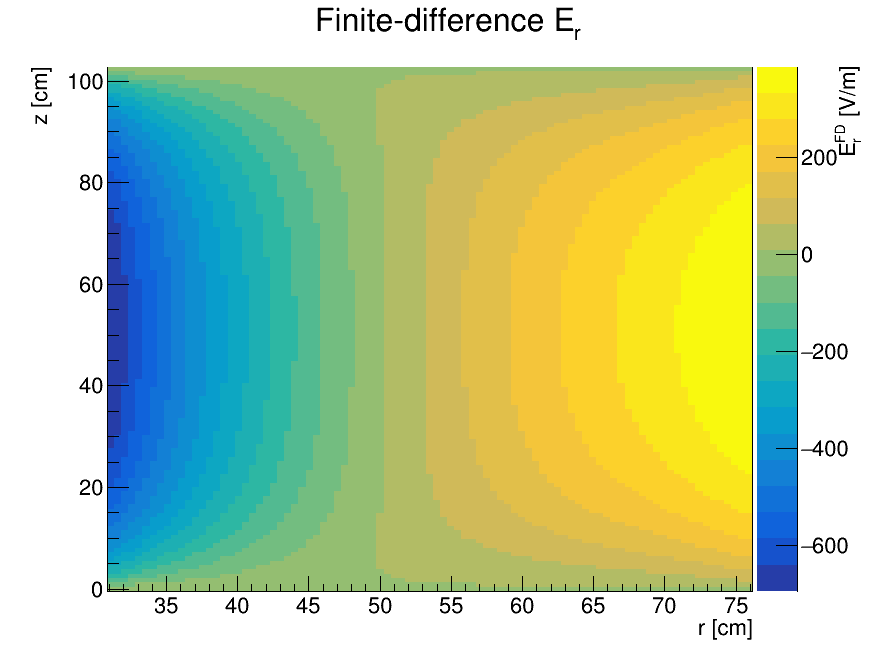

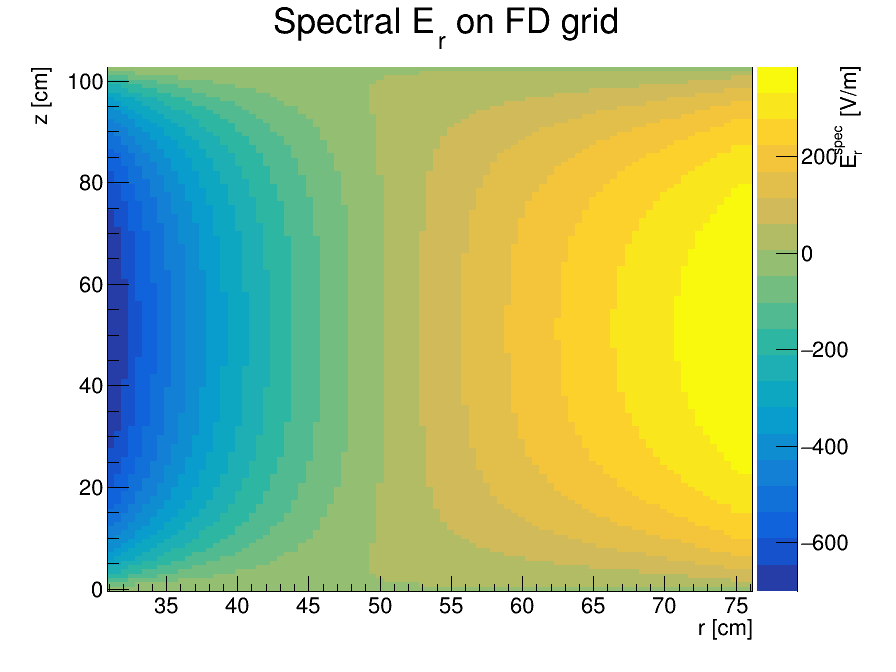

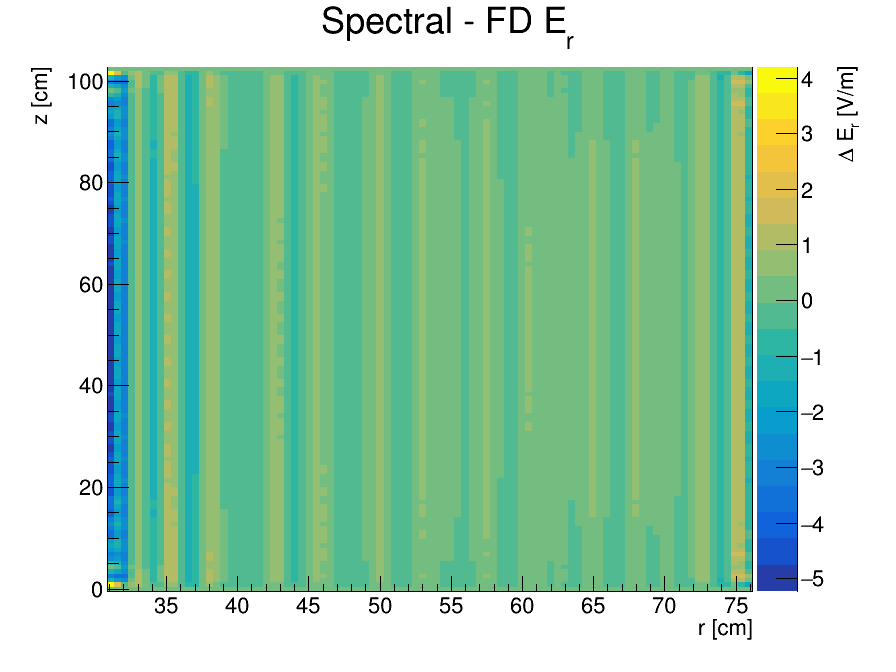

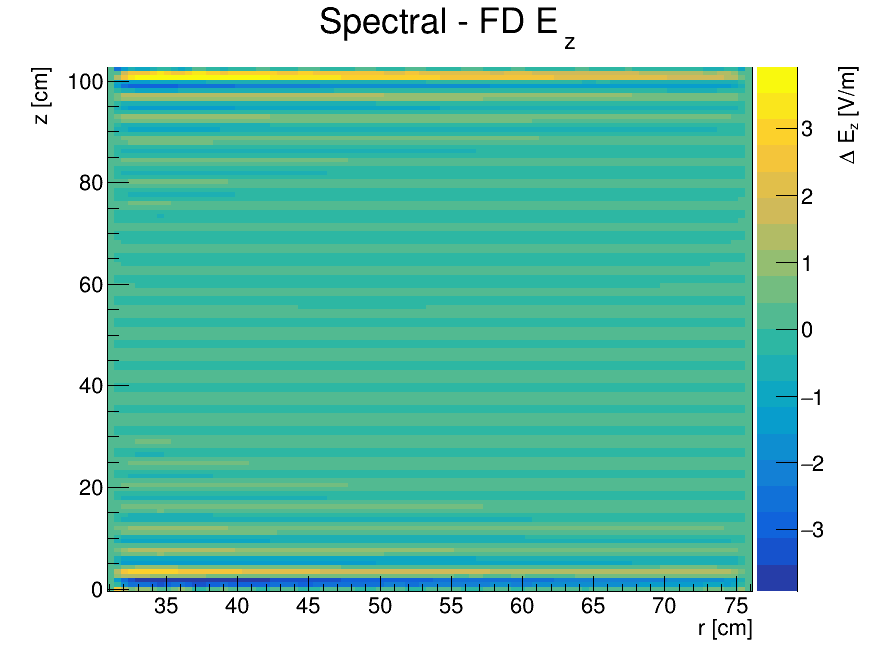

Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_fd_Er.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_spectral_Er_fdgrid.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_Er_fd_residual.png has been created
Info in <TCanvas::Print>: png file spacecharge_qa_plots/qa_Ez_fd_residual.png has been created


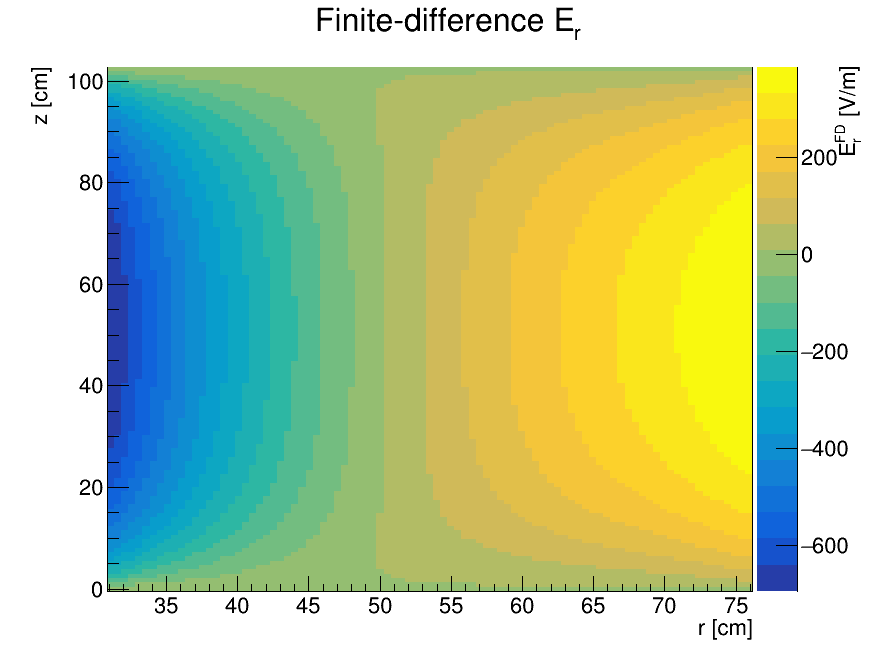

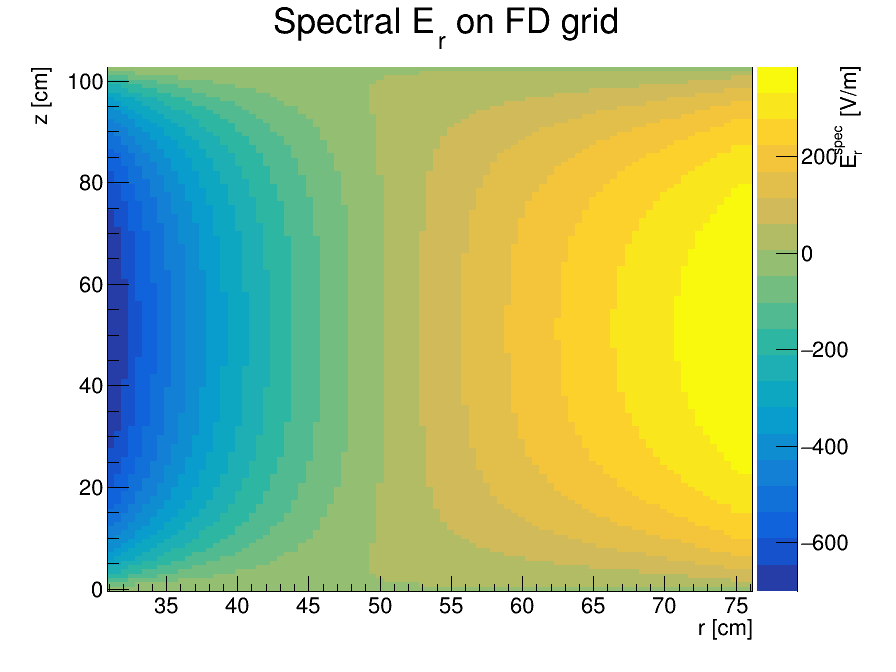

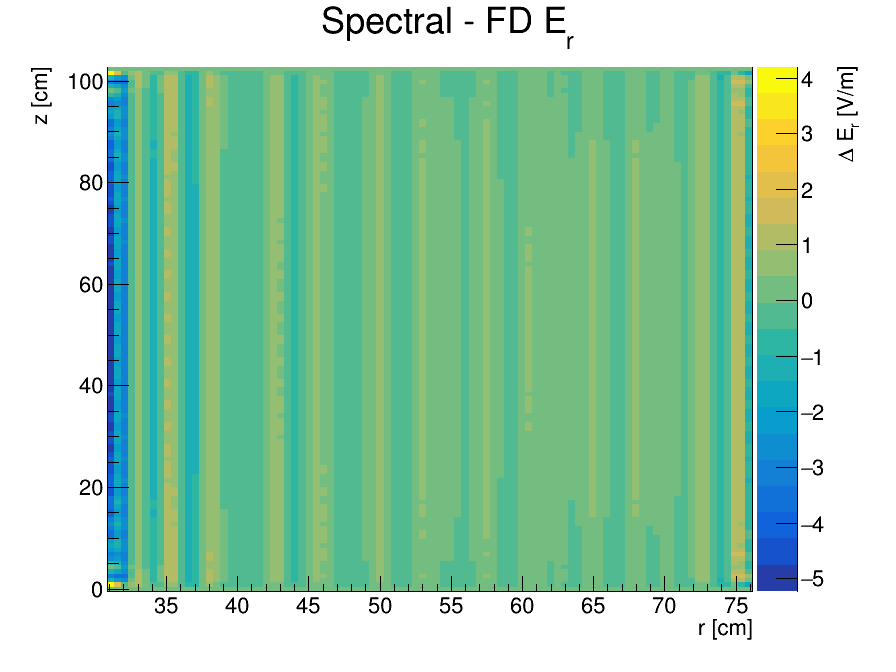

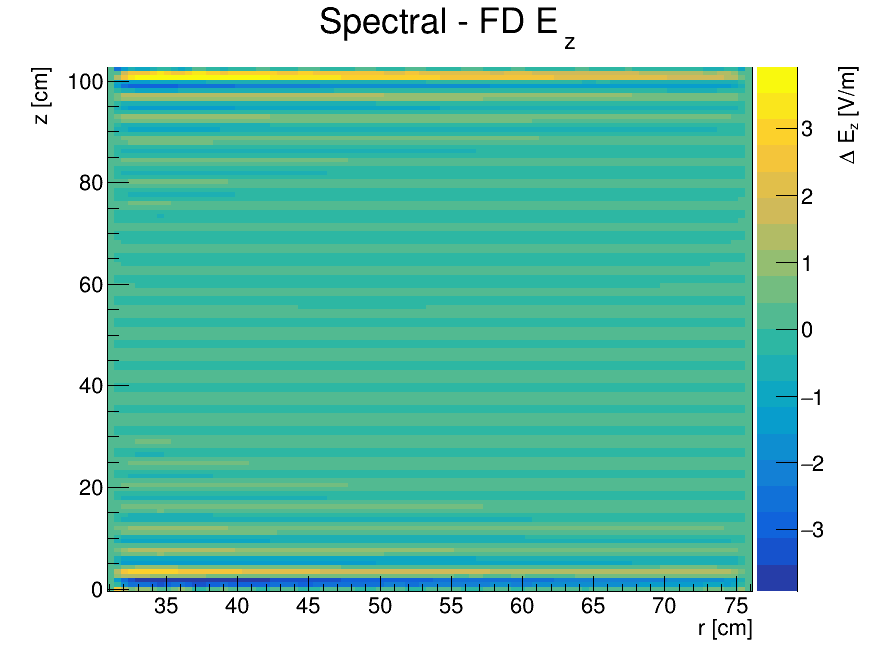

In [ ]:
def solve_axisymmetric_poisson_fd(rho_function, nr_fd=FD_NR, nz_fd=FD_NZ):
    r_fd = np.linspace(a, b, nr_fd)
    z_fd = np.linspace(0.0, L, nz_fd)
    dr = r_fd[1] - r_fd[0]
    dz = z_fd[1] - z_fd[0]

    ni = nr_fd - 2
    nj = nz_fd - 2
    n_unknown = ni * nj

    def idx(i, j):
        # i=1..nr_fd-2, j=1..nz_fd-2
        return (i-1)*nj + (j-1)

    A = sparse.lil_matrix((n_unknown, n_unknown), dtype=np.float64)
    rhs = np.zeros(n_unknown, dtype=np.float64)

    for i in range(1, nr_fd-1):
        r_i = r_fd[i]
        rp = r_i + 0.5*dr
        rm = r_i - 0.5*dr

        c_rp = rp / (r_i * dr**2)
        c_rm = rm / (r_i * dr**2)
        c_z = 1.0 / dz**2
        c_0 = -(c_rp + c_rm + 2*c_z)

        for j in range(1, nz_fd-1):
            row = idx(i, j)
            A[row, row] = c_0

            if i+1 <= nr_fd-2:
                A[row, idx(i+1, j)] = c_rp
            if i-1 >= 1:
                A[row, idx(i-1, j)] = c_rm
            if j+1 <= nz_fd-2:
                A[row, idx(i, j+1)] = c_z
            if j-1 >= 1:
                A[row, idx(i, j-1)] = c_z

            rhs[row] = -rho_function(r_i, z_fd[j]) / EPSILON_0

    phi_inner = sparse_linalg.spsolve(A.tocsr(), rhs)

    phi = np.zeros((nr_fd, nz_fd), dtype=np.float64)
    for i in range(1, nr_fd-1):
        for j in range(1, nz_fd-1):
            phi[i, j] = phi_inner[idx(i, j)]

    Er = np.zeros_like(phi)
    Ez = np.zeros_like(phi)

    Er[1:-1, :] = -(phi[2:, :] - phi[:-2, :]) / (2*dr)
    Ez[:, 1:-1] = -(phi[:, 2:] - phi[:, :-2]) / (2*dz)

    Er[0, :] = -(phi[1, :] - phi[0, :]) / dr
    Er[-1, :] = -(phi[-1, :] - phi[-2, :]) / dr
    Ez[:, 0] = -(phi[:, 1] - phi[:, 0]) / dz
    Ez[:, -1] = -(phi[:, -1] - phi[:, -2]) / dz

    return r_fd, z_fd, phi, Er, Ez

fd_results = None

if DO_FD_CROSSCHECK:
    rho_average = RHO_REFERENCE_NC_PER_M3 * 1e-9

    # Determine continuous normalization for rho ~ 1/r so that the
    # volume-averaged density equals rho_average.
    if CHARGE_PROFILE == "uniform":
        def raw_shape(rr):
            return 1.0
    elif CHARGE_PROFILE == "1/r":
        def raw_shape(rr):
            return a/rr
    elif CHARGE_PROFILE == "1/r2":
        def raw_shape(rr):
            return (a/rr)**2
    else:
        raise ValueError(CHARGE_PROFILE)

    denom = gauss_integrate_interval(lambda rr: rr, a, b, order=256)
    numer = gauss_integrate_interval(
        lambda rr: rr*raw_shape(rr), a, b, order=256
    )
    shape_mean = numer/denom

    def rho_function(rr, zz):
        return rho_average * raw_shape(rr) / shape_mean

    t0 = time.time()
    r_fd, z_fd, phi_fd, Er_fd, Ez_fd = solve_axisymmetric_poisson_fd(
        rho_function
    )
    print(f"FD solve completed in {time.time()-t0:.2f} s")

    # Spectral result evaluated on the FD grid by summing all source charges.
    # Build source modal coefficient for arbitrary total charge distribution.
    modal_source_total = source_projection.T @ Q_vector
    modal_coeff_total = modal_source_total.reshape(
        N_RADIAL_MODES, N_LONGITUDINAL_MODES
    ) / normalization_nm

    def evaluate_total_spectral_field(r_values, z_values):
        R = np.stack([radial_basis(k, r_values) for k in k_modes], axis=1)
        dR = np.stack(
            [radial_basis_derivative(k, r_values) for k in k_modes], axis=1
        )
        SZ = np.sin(z_values[:, None]*q_modes[None, :])
        CZ = np.cos(z_values[:, None]*q_modes[None, :])

        Er = np.zeros((len(r_values), len(z_values)))
        Ez = np.zeros_like(Er)
        for i in range(len(r_values)):
            for j in range(len(z_values)):
                Er[i, j] = np.sum(
                    -modal_coeff_total * np.outer(dR[i], SZ[j])
                )
                Ez[i, j] = np.sum(
                    -modal_coeff_total
                    * np.outer(R[i], q_modes*CZ[j])
                )
        return Er, Ez

    Er_spec_fdgrid, Ez_spec_fdgrid = evaluate_total_spectral_field(r_fd, z_fd)

    fd_results = {
        "r": r_fd, "z": z_fd,
        "phi": phi_fd,
        "Er_fd": Er_fd, "Ez_fd": Ez_fd,
        "Er_spec": Er_spec_fdgrid,
        "Ez_spec": Ez_spec_fdgrid
    }

    # Exclude one-cell boundary layer for summary metrics.
    sl = np.s_[2:-2, 2:-2]
    er_scale = max(np.max(np.abs(Er_fd[sl])), FIELD_FLOOR_V_PER_M)
    ez_scale = max(np.max(np.abs(Ez_fd[sl])), FIELD_FLOOR_V_PER_M)

    print("FD cross-check interior max absolute differences:")
    print("  Er:", np.max(np.abs(Er_spec_fdgrid[sl]-Er_fd[sl])), "V/m")
    print("  Ez:", np.max(np.abs(Ez_spec_fdgrid[sl]-Ez_fd[sl])), "V/m")
    print("FD cross-check normalized to FD max field:")
    print("  Er:", np.max(np.abs(Er_spec_fdgrid[sl]-Er_fd[sl]))/er_scale)
    print("  Ez:", np.max(np.abs(Ez_spec_fdgrid[sl]-Ez_fd[sl]))/ez_scale)

if DO_QA:
    er_residual = Er_spec_fdgrid - Er_fd
    ez_residual = Ez_spec_fdgrid - Ez_fd

    # Build edges around the FD nodes for visualization.
    rfd_edges = np.linspace(a-(r_fd[1]-r_fd[0])/2,
                            b+(r_fd[1]-r_fd[0])/2,
                            len(r_fd)+1)
    zfd_edges = np.linspace(-(z_fd[1]-z_fd[0])/2,
                            L+(z_fd[1]-z_fd[0])/2,
                            len(z_fd)+1)

    h_fd_er = numpy_to_th2(
        "hFDEr", "Finite-difference E_{r}; r [cm]; z [cm]",
        Er_fd, rfd_edges, zfd_edges, "E_{r}^{FD} [V/m]"
    )
    h_spec_er = numpy_to_th2(
        "hSpectralErFDGrid", "Spectral E_{r} on FD grid; r [cm]; z [cm]",
        Er_spec_fdgrid, rfd_edges, zfd_edges, "E_{r}^{spec} [V/m]"
    )
    h_res_er = numpy_to_th2(
        "hErFDResidual", "Spectral - FD E_{r}; r [cm]; z [cm]",
        er_residual, rfd_edges, zfd_edges, "#Delta E_{r} [V/m]"
    )
    h_res_ez = numpy_to_th2(
        "hEzFDResidual", "Spectral - FD E_{z}; r [cm]; z [cm]",
        ez_residual, rfd_edges, zfd_edges, "#Delta E_{z} [V/m]"
    )

    qa_objects += [h_fd_er, h_spec_er, h_res_er, h_res_ez]
    qa_canvases += [
        draw_th2("qa_fd_Er", h_fd_er),
        draw_th2("qa_spectral_Er_fdgrid", h_spec_er),
        draw_th2("qa_Er_fd_residual", h_res_er),
        draw_th2("qa_Ez_fd_residual", h_res_ez),
    ]


## 18. Linearity and amplitude scan

Poisson's equation is linear in charge density. Therefore

$$
\mathbf E[c\,\rho]=c\,\mathbf E[\rho].
$$

The expensive kernel is generated only once. Scanning the unknown ion-backflow amplitude requires only a matrix-vector multiplication—or, for a fixed shape, a scalar multiplication of the reference field.

This is the intended interface for later scans against track DCA and reconstructed momentum.

In [ ]:
amplitude_scan = {}

for scale in RHO_SCALE_FACTORS:
    amplitude_scan[scale] = {
        "rho_nC_per_m3": scale * RHO_REFERENCE_NC_PER_M3,
        "Er": scale * E_r_grid,
        "Ez": scale * E_z_grid
    }

if DO_QA:
    # Explicit superposition test using two arbitrary source voxels.
    q1 = (nr//3)*nz + (nz//3)
    q2 = (2*nr//3)*nz + (2*nz//3)

    charges = np.zeros(nvox)
    charges[q1] = 2.3e-15
    charges[q2] = 4.1e-15

    er_sum = K_r @ charges
    er_parts = K_r[:, q1]*charges[q1] + K_r[:, q2]*charges[q2]
    ez_sum = K_z @ charges
    ez_parts = K_z[:, q1]*charges[q1] + K_z[:, q2]*charges[q2]

    print("Superposition residual Er:", np.max(np.abs(er_sum-er_parts)))
    print("Superposition residual Ez:", np.max(np.abs(ez_sum-ez_parts)))

Superposition residual Er: 0.0
Superposition residual Ez: 0.0


## 19. Write the ROOT file

The primary kernel is stored as two `TMatrixD` objects:

- `K_r`: rows are observation voxels, columns are source voxels;
- `K_z`: same indexing.

The flattening convention is

$$
\text{index}=i_rN_z+i_z.
$$

The file also contains:

- radial and longitudinal edges;
- cell volumes;
- default density and field maps;
- representative source-response maps;
- metadata describing geometry, units, modes, and normalization.

The kernel is normalized per source charge in coulombs. To construct a field, form the source-charge vector

$$
Q_q=\rho_qV_q
$$

and calculate

$$
E_{\alpha,p}=\sum_qK_{\alpha,pq}Q_q.
$$

In [ ]:
def numpy_to_tmatrix(array):
    arr = np.asarray(array, dtype=np.float64)
    mat = root.TMatrixD(arr.shape[0], arr.shape[1])
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            mat[i][j] = float(arr[i, j])
    return mat

def numpy_to_tvector(array):
    arr = np.asarray(array, dtype=np.float64).ravel()
    vec = root.TVectorD(len(arr))
    for i, value in enumerate(arr):
        vec[i] = float(value)
    return vec

if WRITE_ROOT_OUTPUT:
    fout = root.TFile(OUTPUT_ROOT_FILE, "RECREATE")
    if not fout or fout.IsZombie():
        raise OSError(f"Could not create {OUTPUT_ROOT_FILE}")

    # Metadata as TNamed strings for broad ROOT compatibility.
    metadata = {
        "geometry": {
            "r_inner_m": a,
            "r_outer_m": b,
            "drift_length_m": L
        },
        "grid": {
            "nr": nr, "nz": nz,
            "flattening": "index = ir*nz + iz"
        },
        "modes": {
            "n_radial": N_RADIAL_MODES,
            "n_longitudinal": N_LONGITUDINAL_MODES
        },
        "kernel": {
            "normalization": "electric field per full annular source-cell charge",
            "units": "(V/m)/C",
            "boundary_condition": "homogeneous Dirichlet perturbation potential",
            "azimuthal_mode": 0
        },
        "default_charge": {
            "radial_profile": CHARGE_PROFILE,
            "z_profile": Z_PROFILE,
            "volume_average_nC_per_m3": RHO_REFERENCE_NC_PER_M3
        }
    }

    root.TNamed("metadata_json", json.dumps(metadata, indent=2)).Write()
    root.TNamed(
        "indexing",
        "observation/source flat index = ir*nz + iz; z is the fast index"
    ).Write()

    numpy_to_tvector(r_edges).Write("r_edges_m")
    numpy_to_tvector(z_edges).Write("z_edges_m")
    numpy_to_tvector(r_centers).Write("r_centers_m")
    numpy_to_tvector(z_centers).Write("z_centers_m")
    numpy_to_tvector(cell_volumes.ravel()).Write("cell_volumes_m3")
    numpy_to_tvector(k_modes).Write("radial_k_modes_per_m")
    numpy_to_tvector(q_modes).Write("longitudinal_q_modes_per_m")

    print("Converting K_r to TMatrixD...")
    numpy_to_tmatrix(K_r).Write("K_r")
    print("Converting K_z to TMatrixD...")
    numpy_to_tmatrix(K_z).Write("K_z")

    qa_dir = fout.mkdir("QA")
    qa_dir.cd()
    for obj in qa_objects:
        obj.Write()
    for canvas in globals().get('qa_canvases', []):
        canvas.Write()

    fout.cd()
    fout.Write()
    fout.Close()

    print(f"Wrote ROOT output: {OUTPUT_ROOT_FILE}")

Converting K_r to TMatrixD...
Converting K_z to TMatrixD...
Wrote ROOT output: sphenix_axisymmetric_spacecharge_kernel.root


## 20. Final numerical summary

Before using the kernel for electron transport, verify:

1. radial mode boundary residuals are small;
2. radial overlap is nearly diagonal;
3. reflection symmetries hold;
4. mode scans are stable at representative points;
5. the enclosed Gauss test approaches $1$;
6. the excluded Gauss test approaches $0$;
7. the finite-difference field agrees in shape and scale away from boundaries;
8. fields scale linearly with charge amplitude.

A coarse initial grid is suitable for validating the machinery. It is not yet a final calibration map. Once QA passes, increase mode counts first, then refine source and observation grids, checking that the resulting physical field and later track distortions are stable.

In [ ]:
summary = {
    "grid": {
        "nr": nr,
        "nz": nz,
        "nvox": nvox,
        "dr_mean_cm": float(np.mean(np.diff(r_edges))*100),
        "dz_mean_cm": float(np.mean(np.diff(z_edges))*100)
    },
    "default_charge": {
        "profile": CHARGE_PROFILE,
        "rho_average_nC_per_m3": RHO_REFERENCE_NC_PER_M3,
        "Q_total_C_one_side": float(Q_vector.sum())
    },
    "field": {
        "max_abs_Er_V_per_m": float(np.max(np.abs(E_r_grid))),
        "max_abs_Ez_V_per_m": float(np.max(np.abs(E_z_grid))),
        "max_Emag_V_per_m": float(np.max(E_mag_grid))
    },
    "gauss": gauss_results
}

print(json.dumps(summary, indent=2))

{
  "grid": {
    "nr": 12,
    "nz": 26,
    "nvox": 312,
    "dr_mean_cm": 3.733833333333334,
    "dz_mean_cm": 3.935576923076923
  },
  "default_charge": {
    "profile": "1/r",
    "rho_average_nC_per_m3": 20.0,
    "Q_total_C_one_side": 3.08280823392274e-08
  },
  "field": {
    "max_abs_Er_V_per_m": 601.4974634839555,
    "max_abs_Ez_V_per_m": 354.7793501535564,
    "max_Emag_V_per_m": 601.4976550895649
  },
  "gauss": {
    "enclosed": {
      "flux": 113066253039.66954,
      "epsilon0_flux_over_Q": 1.001109839702803
    },
    "excluded": {
      "flux": 676651.9866683483,
      "epsilon0_flux_over_Q": 5.9912037738657985e-06
    }
  }
}


: 

## 21. Next step: convert the electric field into electron distortions

This notebook stops at the electric-field kernel. The next notebook stage will combine

$$
\mathbf E_{\rm total}
=
E_0\hat z+\delta\mathbf E
$$

with the sPHENIX magnetic field and gas transport coefficients. The electron drift velocity follows the steady-state Langevin response. Integrating the transverse and longitudinal velocity perturbations from a production point to the readout plane gives

$$
\Delta r(r,z),\qquad
\Delta(r\phi)(r,z),\qquad
\Delta z(r,z).
$$

Even though the charge model is axisymmetric, a radial electric field in a solenoidal magnetic field generally produces both radial and azimuthal electron displacement through the Lorentz term. Therefore $E_\phi=0$ does **not** imply $\Delta(r\phi)=0$.

That transport stage should be kept separate from the electrostatic kernel so that charge-amplitude scans, gas-parameter scans, and magnetic-field variations do not require rebuilding the Green-function response.

## References used for the implementation

1. Stefan Rossegger, *Simulation and Calibration of the ALICE Time-Projection Chamber including innovative Space Charge Calculations*, especially Chapter 5 and Appendix A.
2. T. K. Hemmick, *Space Charge in the sPHENIX TPC / Lost in Space*, especially the factorization into the nominal graded field plus the grounded-cavity space-charge field, the $m_\phi=0$ simplification, and the Gauss-law validation strategy.

The formulas in this notebook are specialized to the axisymmetric finite-annular-voxel problem and written with explicit SI normalization.